In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gc
import datetime

**Carga y Visualizacion de los Datos**

- EL DATASET QUE UTILIZAMOS ES EL GENERADO EN EL NOTEBOOK "8 ANALISIS_PREDICCIONES_historico_2014.ipynb". 

In [3]:
#CARGO LOS DATOS DEL DATASET GENERADO EN EL NOTEBOOK "ANALISIS_PREDICCIONES_historico_2014.ipynb".
df2=pd.read_csv("df2014.csv", encoding='latin1')

In [4]:
df2.head()

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
0,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_E_TURN02,FLORIDA,7,1,2,7,10
1,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_E_TURN03,FLORIDA,9,1,2,9,12
2,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN01,FLORIDA,14,1,2,16,17
3,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN02,FLORIDA,18,1,2,18,21
4,2014-04-09,09:15:00,09:29:00,B,LINEA_B_FLORIDA_O_TURN03,FLORIDA,12,1,2,12,15


In [5]:
df2.describe()

,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
count,1.085724e+07,1.085724e+07,1.085724e+07,1.085724e+07,1.085724e+07
mean,2.278287e+01,9.672220e-01,1.938764e+00,2.350409e+01,2.568886e+01
std,2.676069e+01,4.512921e-01,1.496726e+00,2.772856e+01,2.723842e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,7.000000e+00
50%,1.400000e+01,1.000000e+00,2.000000e+00,1.400000e+01,1.600000e+01
75%,3.100000e+01,1.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01
max,1.453700e+04,6.500000e+01,9.900000e+01,1.453800e+04,1.453900e+04


In [5]:
#LO ORDENO DE MAYOR A MENOR
dfsinoutlier = df2.sort_values(by='PAX_PAGO', ascending=False)

In [6]:
#ME ASEGURO DE QUE ESE SEA EL UNICO OUTLIER O HAY ALGUNO MAS, VOY A TOMAR LOS 3 MAS ALTOS.

dfsinoutlier[['PAX_PAGO']].head(3)

,PAX_PAGO
2569691,14537
5845761,317
5845760,316


In [7]:
#LOS IDENTIFICO
outliers = 1

outliers_mas_altos = dfsinoutlier.head(outliers)
print(outliers_mas_altos)
#LOS IDENTIFICO NUEVAMENTE PARA VER SI SON LOS MISMOS
rmax = dfsinoutlier.nlargest(outliers,'PAX_PAGO')
rmax.head()

              FECHA     DESDE     HASTA LINEA               MOLINETE  \
2569691  2014-07-08  17:00:00  17:14:00     B  LINEA_B_ALEM_N_TURN02   

                ESTACION  PAX_PAGO  PAX_PASES_PAGOS  PAX_FRANQ  PAX_TOTAL  \
2569691  LEANDRO N. ALEM     14537                1          1      14538   

         TOTAL  
2569691  14539  


,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
2569691,2014-07-08,17:00:00,17:14:00,B,LINEA_B_ALEM_N_TURN02,LEANDRO N. ALEM,14537,1,1,14538,14539


In [8]:
#CREO UN NUEVO DATAFRAME EL CUAL VA A SER EL QUE SE UTILIZARA PARA LOS MODELOS DE PREDICCION DE MACHINE LEARNING Y LUEGO DEEP LEARNING.

#ELIMINO LOS OUTLIERS MAS ALTOS DETECTADOS EN EL PUNTO ANTERIOR.
dfsinoutlierok = dfsinoutlier.drop(outliers_mas_altos.index)

In [9]:
dfsinoutlierok[['PAX_PAGO']].head(3)

,PAX_PAGO
5845761,317
5845760,316
5885983,303


In [10]:
dfsinoutlierok.head()

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL
5845761,2014-11-05,08:30:00,08:44:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,317,2,2,321,321
5845760,2014-11-05,08:15:00,08:29:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,316,3,7,326,326
5885983,2014-11-10,08:00:00,08:14:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,303,0,3,306,306
5861850,2014-11-07,08:15:00,08:29:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,295,1,2,298,298
5853805,2014-11-06,08:15:00,08:29:00,B,LINEA_B_JMROSAS_ESTE_TURN02,ROSAS,292,0,1,293,293


**Preparacion de los datos para su posterior anaisis**

In [11]:
#CREO UN NEVO DATAFRAME "df3" PARA UTILIZARLO EN EL ANALISIS Y LUEGO DEEP LEARNING.
df3 = dfsinoutlierok

In [12]:
print(df3['FECHA'].isnull().sum())

0


In [13]:
#CONVIERTO LA COLUMNA DESDE A TIPO FECHA Y HORA.
df3['DESDE'] = pd.to_datetime(dfsinoutlierok['DESDE'])
#CONVIERTO LA COLUMNA HORA a tipo hour y minute.
df3['HORA']=df3['DESDE'].dt.hour + df3['DESDE'].dt.minute / 60



/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_71892/2017409876.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df3['DESDE'] = pd.to_datetime(dfsinoutlierok['DESDE'])


In [14]:
#CONVIERTO LOS VALORES DE LAS LINEAS, ESTACIONES Y MOLINETES A VALORES NUMERICOS.
df3['LINEA'] = pd.factorize(dfsinoutlierok['LINEA'])[0] + 1
df3['ESTACION'] = pd.factorize(dfsinoutlierok['ESTACION'])[0] + 1
df3['MOLINETE'] = pd.factorize(dfsinoutlierok['MOLINETE'])[0] + 1

#CONVIERTO LA COLUMNA FECHA A TIPO FECHA Y LUEGO A TIPO ENTERO.
df3['FECHA'] = pd.to_datetime(df3['FECHA'])
df3['FECHA'] = df3['FECHA'].dt.strftime('%Y%m%d').astype(int)

In [15]:
#VISUALIZO EL DATAFRAME MODIFICADO.
df3.sample(5)

,FECHA,DESDE,HASTA,LINEA,MOLINETE,ESTACION,PAX_PAGO,PAX_PASES_PAGOS,PAX_FRANQ,PAX_TOTAL,TOTAL,HORA
6947275,20141208,2025-04-28 13:45:00,13:59:00,4,352,59,0,1,0,0,1,13.75
8262926,20140115,2025-04-28 16:15:00,16:29:00,1,416,20,37,1,3,40,41,16.25
10777748,20140428,2025-04-28 20:15:00,20:29:00,4,62,17,55,3,2,60,60,20.25
3525303,20140825,2025-04-28 06:45:00,06:59:00,1,78,1,64,1,4,69,69,6.75
7841751,20141210,2025-04-28 14:15:00,14:29:00,3,400,75,23,1,5,29,29,14.25


In [17]:
df3.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'HORA'],
      dtype='object')

In [16]:
#CREO UN NUEVO DATAFRAME CON LAS COLUMNAS QUE ME INTERESAN EN EL ORDEN QUE QUIERO PARA EL MODELO.
#EN ESTE CASO DEJO "PAX_PAGO" PRIMERA COMO VARIABLE A PREDECIR.
df4=df3[['PAX_PAGO', 'LINEA', 'ESTACION','MOLINETE','PAX_PASES_PAGOS', 'PAX_FRANQ', 'TOTAL','FECHA','HORA']]

In [19]:
df4.columns

Index(['PAX_PAGO', 'LINEA', 'ESTACION', 'MOLINETE', 'PAX_PASES_PAGOS',
       'PAX_FRANQ', 'TOTAL', 'FECHA', 'HORA'],
      dtype='object')

In [17]:
#GRABO EL DATAFRAME EN UN ARCHIVO CSV PARA UTILIZARLO LUEGO CON REDES NEURONALES.
df4.to_csv('df2014DL.csv', index=False)

In [21]:
df4.head()

,PAX_PAGO,LINEA,ESTACION,MOLINETE,PAX_PASES_PAGOS,PAX_FRANQ,TOTAL,FECHA,HORA
5845761,317,1,1,1,2,2,321,20141105,8.50
5845760,316,1,1,1,3,7,326,20141105,8.25
5885983,303,1,1,1,0,3,306,20141110,8.00
5861850,295,1,1,1,1,2,298,20141107,8.25
5853805,292,1,1,1,0,1,293,20141106,8.25


## PREPARACION Y ANALISIS DE DATOS PARA POSTERIOR PRUEBA CON REDES NEURONALES

In [18]:
#CREO UN NUEVO DATAFRAME CON df2.
dfdatetime = dfsinoutlierok

**PREPARACION DE LOS DATOS**

In [19]:
#CONVIERTO LA COLUMNA DESDE A TIPO FECHA Y HORA.
dfdatetime['FECHA'] = pd.to_datetime(dfdatetime['FECHA'], format= '%Y%m%d')


In [20]:
#CONIERTO LA COLUMNA DIA_SEMANA A TIPO ENTERO.
dfdatetime['DIA_SEMANA']= dfdatetime['FECHA'].dt.dayofweek

In [21]:
dfdatetime.columns

Index(['FECHA', 'DESDE', 'HASTA', 'LINEA', 'MOLINETE', 'ESTACION', 'PAX_PAGO',
       'PAX_PASES_PAGOS', 'PAX_FRANQ', 'PAX_TOTAL', 'TOTAL', 'HORA',
       'DIA_SEMANA'],
      dtype='object')

In [22]:
# Agrego columna con y separo los meses del año para cada estación climatica.
dfdatetime['ESTACION_ANIO'] = dfdatetime['FECHA'].dt.month.apply(lambda x: 'Verano' if x in [12, 1, 2] else 'Otoño' if x in [3, 4, 5] else 'Invierno' if x in [6, 7, 8] else 'Primavera')

# Agrego columna para los días festivos
dfdatetime['DIA_FESTIVO'] = dfdatetime['FECHA'].dt.date.apply(lambda x: 1 if x.month == 1 and x.day == 1 else 0)

# Realizo análisis considerando los nuevos factores
dia_semana_avg = dfdatetime.groupby(['DIA_SEMANA', 'ESTACION_ANIO', 'DIA_FESTIVO'])['PAX_PAGO'].mean().reset_index()



## Visualizacion Grafica e Interpretacion de los datos.

In [23]:
# Aseguro el orden correcto de los días (0 = Lunes, 6 = Domingo)
dia_semana_avg = dia_semana_avg.sort_values('DIA_SEMANA')

**SIGUIENTE GRAFICO: ANALISIS POR DIA DE LA SEMANA**

- El codigo siguiente, genera un gráfico de barras que representa el promedio de pasajeros pagos que se transportan en el subterraneo según el día de la semana.

1. En el eje X (horizontal) están los días de la semana: de lunes a domingo.
1. En el eje Y (vertical) está el promedio de pasajeros pagos por día.

- . Este gráfico nos permite identificar patrones semanales de uso del transporte:

**¿Para qué sirve?**

- . Nos permite saber qué días tienen mayor demanda (más pasajeros).
- . Qué días tienen menos movimiento.
- . Comparar la diferencia entre días laborables y fines de semana.

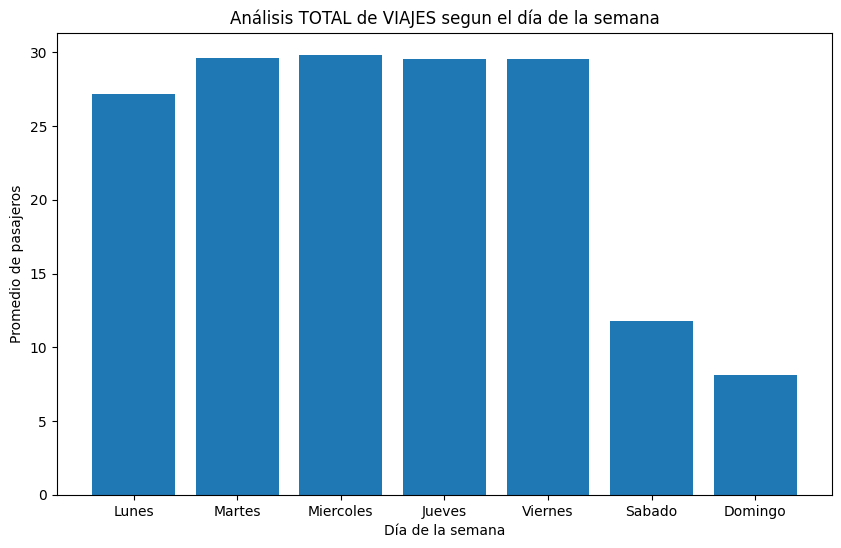

In [24]:
# Visualizo la cantidad de viajes segun el día de la semana.
plt.figure(figsize=(10, 6))
plt.bar(dia_semana_avg['DIA_SEMANA'], dia_semana_avg['PAX_PAGO'])
plt.xlabel('Día de la semana')
plt.ylabel('Promedio de pasajeros')
plt.title('Análisis TOTAL de VIAJES segun el día de la semana')
plt.xticks([0,1,2,3,4,5,6,],['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo'])
plt.show()


**SIGUIENTE GRAFICO: ANALISIS POR HORA**

- El siguiente codigo, genera un gráfico de líneas que muestra cómo varía el promedio de pasajeros pagos (PAX_PAGO) a lo largo del día, hora por hora.

**¿Qué se visualiza con este gráfico?**

1. Eje X (horizontal): Representa la hora del día (por ejemplo, 0 a 23 si es formato de 24 hs).
2. Eje Y (vertical): Muestra el promedio de pasajeros pagos registrados en cada hora, calculado sobre todos los días del dataset.

La línea refleja cómo cambia la cantidad promedio de pasajeros con el paso de las horas.

Interpretación simple:

1. Los picos representan las horas donde más gente viaja, por ejemplo:
. A la mañana temprano (horario laboral/escolar).
. A la tarde/noche (vuelta a casa).

2. Los valles o zonas bajas en horas de poco movimiento, como la madrugada.
- Esto, nos permite entender los momentos de mayor uso del subte.

**¿Para qué sirve?**

- Este grafico, es Útil para planificación operativa, como refuerzos de trenes en horas pico.
- También para modelar la demanda horaria o aplicar técnicas de predicción según la hora.

Text(0.5, 1.0, 'Comportamiento de los Viajes (Promedio) segun la HORA del día.')

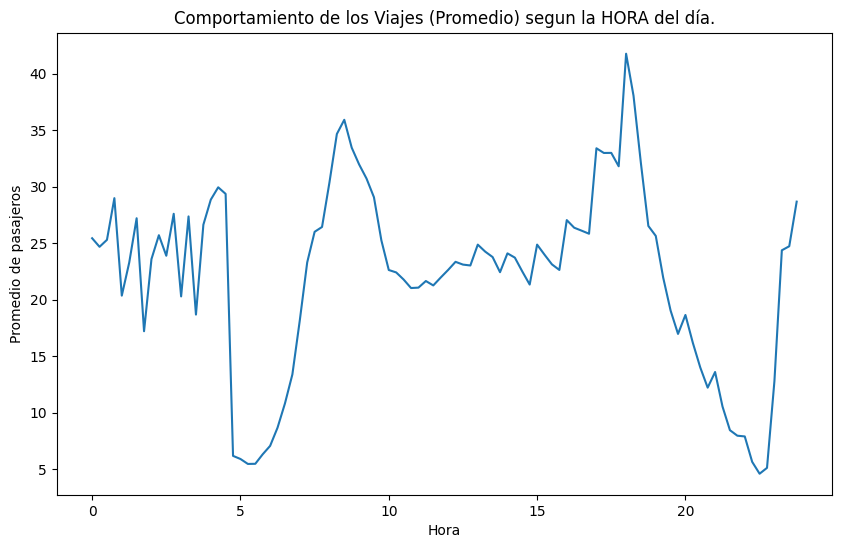

In [29]:
# Visualizo el comportamiento de los viajes (Promedio) segun la hora del día.
hora_avg = dfdatetime.groupby('HORA')['PAX_PAGO'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(hora_avg['HORA'], hora_avg['PAX_PAGO'])
plt.xlabel('Hora')
plt.ylabel('Promedio de pasajeros')
plt.title('Comportamiento de los Viajes (Promedio) segun la HORA del día.')

**SIGUIENTE GRAFICO: ANALISIS POR MES**

- El siguiente código, genera un gráfico que muestra el promedio de (pasajeros pagos) por mes ordenado de (Enero a Diciembre).

**¿Qué se visualiza?**

- Cada barra representa un mes del año.

- Interpretación simple:
- El alto de cada barra muestra el promedio de pasajeros pagos ese mes.

**¿Para qué sirve?**

- Permite detectar meses con mayor o menor movimiento, como vacaciones de verano (Enero/Febrero), inicio de clases (Marzo), o meses con feriados largos.

In [30]:
# Asegurate de que la columna de fecha esté en formato datetime
dfdatetime['FECHA'] = pd.to_datetime(dfdatetime['FECHA'])

# Filtrar solo los datos del año 2014
df_2014 = dfdatetime[dfdatetime['FECHA'].dt.year == 2014]


/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_62777/760666900.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mes_avg = df_2014.groupby('MES')['PAX_PAGO'].mean().reset_index()


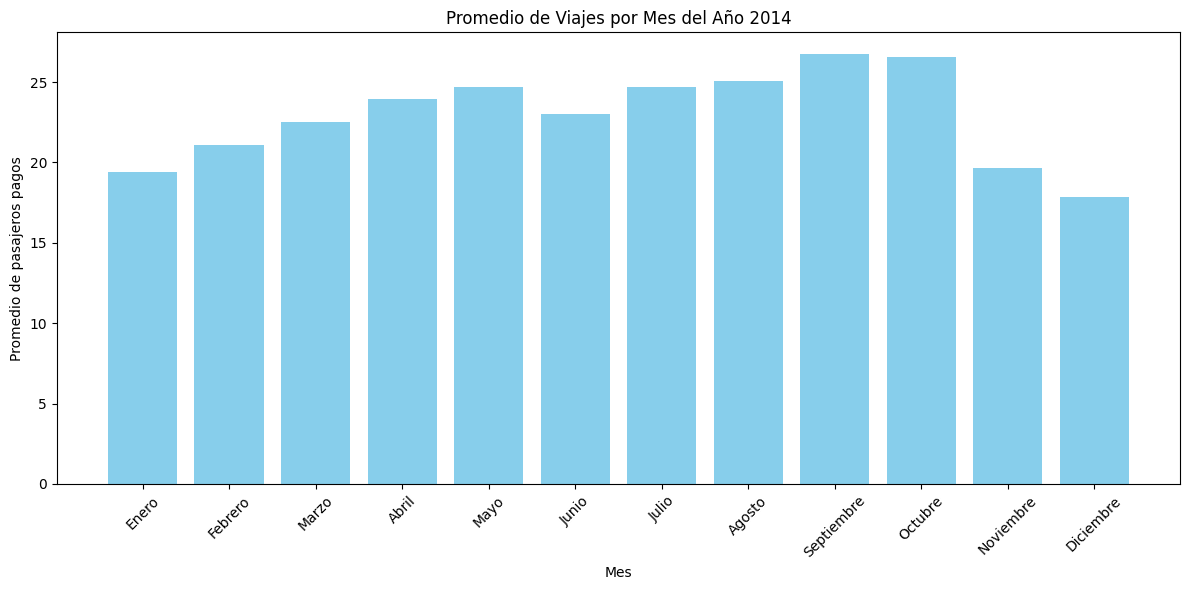

In [31]:
# Crear columna con número del mes
df_2014['MES_NUM'] = df_2014['FECHA'].dt.month

# Diccionario de mapeo a meses en español
meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

# Crear columna con nombre del mes en español
df_2014['MES'] = df_2014['MES_NUM'].map(meses_es)

# Orden correcto de los meses en español
orden_meses_es = list(meses_es.values())
df_2014['MES'] = pd.Categorical(df_2014['MES'], categories=orden_meses_es, ordered=True)

# Agrupar por mes y calcular el promedio de pasajeros pagos
mes_avg = df_2014.groupby('MES')['PAX_PAGO'].mean().reset_index()

# Graficar
plt.figure(figsize=(12, 6))
plt.bar(mes_avg['MES'], mes_avg['PAX_PAGO'], color='skyblue')
plt.xlabel('Mes')
plt.ylabel('Promedio de pasajeros pagos')
plt.title('Promedio de Viajes por Mes del Año 2014')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**SIGUIENTE GRAFICO: ANALISIS POR MES POR LINEA**


El siguiente gráfico muestra el promedio mensual de (pasajeros pagos) para cada línea de subte durante el año 2014.

- Cada línea del gráfico representa una línea de subterráneo (por ejemplo, LÍNEA A, B, C, etc.), y la curva muestra cómo varió su uso a lo largo de los meses del año.

**¿Cómo se compone?**

1. Eje X (horizontal): Los meses del año 2014 en español (de Enero a Diciembre).
2. Eje Y (vertical): El promedio de pasajeros pagos registrados en cada línea durante cada mes.

- Líneas de colores: Cada color representa una línea distinta de subte, con un marcador (•) en cada punto mensual.
- Leyenda (a la derecha): Indica a qué línea de subte corresponde cada color.

**¿Para qué sirve?**

Este tipo de visualización permite:
1. Comparar líneas entre sí:
2. Ver qué líneas tienen más o menos uso promedio durante el año.
3. Identificar líneas con más estabilidad o mayor variación mensual.
4. Detectar patrones estacionales o cambios en la demanda:
- Por ejemplo, si hay una caída general en enero (vacaciones) o un pico en marzo (inicio de clases/trabajo).
- Observar comportamientos atípicos en ciertas líneas (picos por eventos, obras, etc.).

Toma de decisiones operativas:
1. Sirve como base para ajustar frecuencias, mantenimiento o personal según la demanda esperada por mes.
2. Útil para estudios de movilidad urbana y planificación del transporte público.

In [32]:
import seaborn as sns

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_62777/3448102701.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mes_linea_avg = df_2014.groupby(['MES', 'LINEA'])['PAX_PAGO'].mean().reset_index()


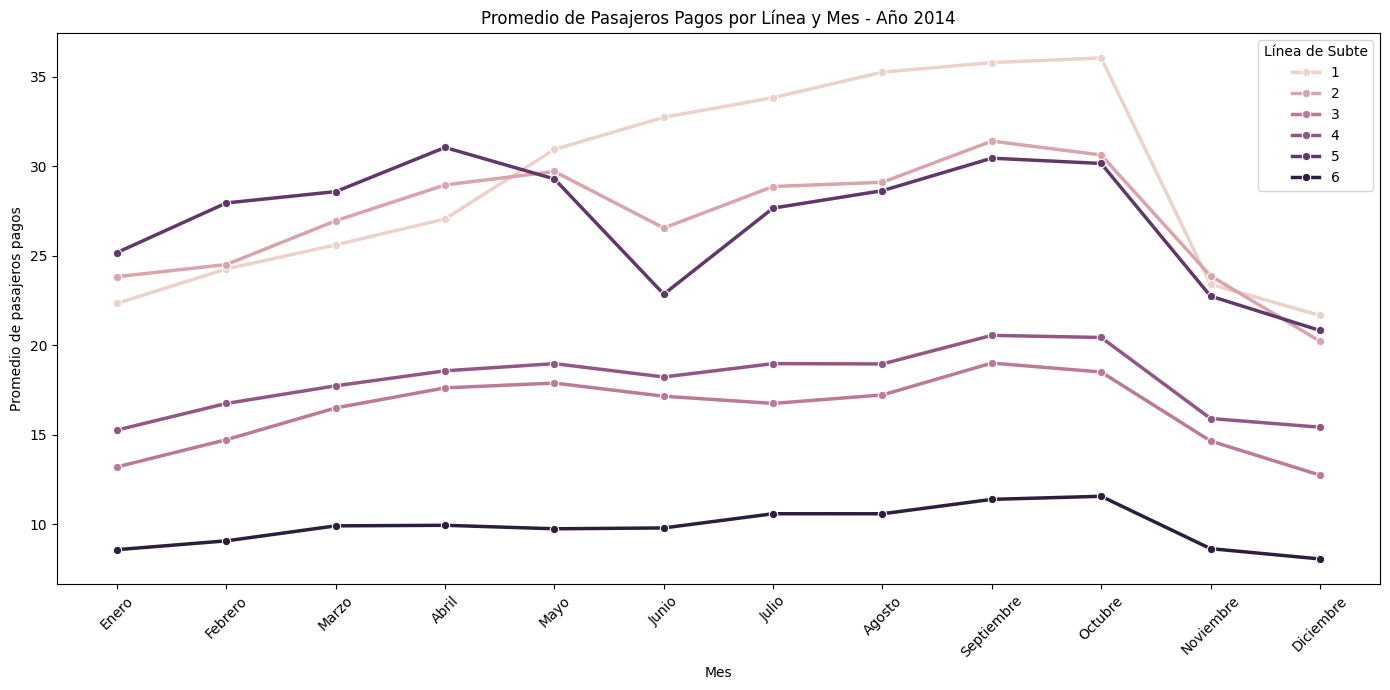

In [33]:

# Crear columna con número del mes
df_2014['MES_NUM'] = df_2014['FECHA'].dt.month

# Mapeo de número a nombre del mes en español
meses_es = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

# Crear columna MES en español
df_2014['MES'] = df_2014['MES_NUM'].map(meses_es)

# Orden correcto de los meses
orden_meses_es = list(meses_es.values())
df_2014['MES'] = pd.Categorical(df_2014['MES'], categories=orden_meses_es, ordered=True)

# Agrupar por MES y LINEA, calculando el promedio de PAX_PAGO
mes_linea_avg = df_2014.groupby(['MES', 'LINEA'])['PAX_PAGO'].mean().reset_index()

# Graficar
plt.figure(figsize=(14, 7))
sns.set_palette("dark")
sns.lineplot(data=mes_linea_avg, x='MES', y='PAX_PAGO', hue='LINEA', marker='o', linewidth=2.5)

plt.title('Promedio de Pasajeros Pagos por Línea y Mes - Año 2014')
plt.xlabel('Mes')
plt.ylabel('Promedio de pasajeros pagos')
plt.xticks(rotation=45)
plt.tight_layout()

# Leyenda con texto negro
legend = plt.legend(title='Línea de Subte')
for text in legend.get_texts():
    text.set_color('black')
legend.get_title().set_color('black')

plt.show()


**SIGUIENTE GRAFICO: ANALISIS POR ESTACION CLIMATICA**

- El siguiente codigo, genera un gráfico de barras que muestra de forma clara cómo varía el promedio de viajes (pasajeros pagos) según la estación del año.

**¿Qué se visualiza?**

1. Eje X (horizontal): Las cuatro estaciones del año: Verano, Otoño, Invierno y Primavera.
2. Eje Y (vertical): El promedio de pasajeros pagos (PAX_PAGO) registrado en cada estación, considerando todos los datos del dataset.

Las barras: Representan la cantidad promedio de pasajeros que usaron el servicio en cada estación.

Interpretación simple:
- Permite ver en qué estación del año hay más o menos viajes en promedio.

Por ejemplo:
1. Si Verano tiene una barra más baja, podría deberse a vacaciones y menor actividad.
2. Si Primavera o Otoño tienen valores más altos, puede relacionarse con mayor actividad laboral o escolar.

**¿Para qué sirve?**

- Para entender la influencia del clima y la estacionalidad en el uso del transporte.
- Útil para ajustar recursos (frecuencia, personal) según la época del año.

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_62777/891395315.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estacion_anio_avg = dfdatetime.groupby('ESTACION_ANIO')['PAX_PAGO'].mean().reset_index()


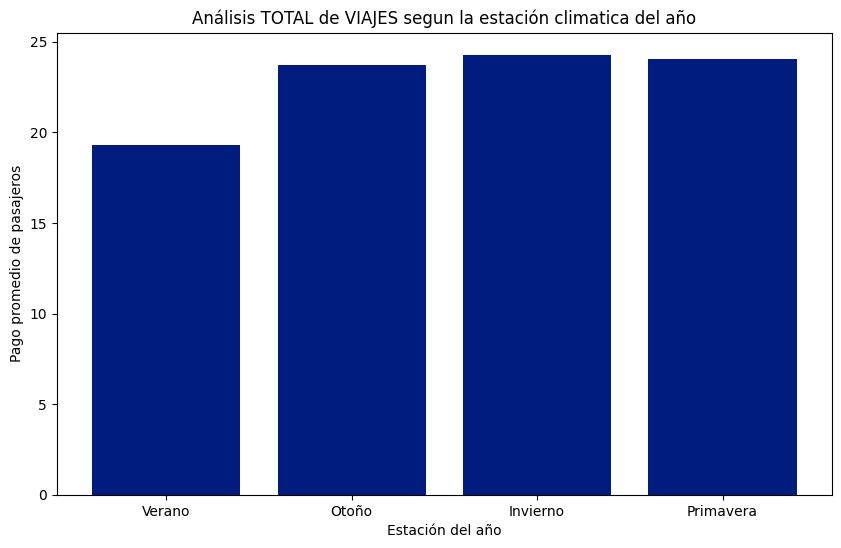

In [34]:
# Visualizo la cantidad de viajes segun la estacion climatica del año.
estacion_orden = ['Verano','Otoño', 'Invierno', 'Primavera']
dfdatetime['ESTACION_ANIO'] = pd.Categorical(dfdatetime['ESTACION_ANIO'],categories=estacion_orden, ordered=True)
estacion_anio_avg = dfdatetime.groupby('ESTACION_ANIO')['PAX_PAGO'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.bar(estacion_anio_avg['ESTACION_ANIO'], estacion_anio_avg['PAX_PAGO'])
plt.xlabel('Estación del año')
plt.ylabel('Pago promedio de pasajeros')
plt.title('Análisis TOTAL de VIAJES segun la estación climatica del año')
plt.show()


## PRUEBA DE DISTINTOS MODELOS DEEP LEARNING

# MODELOS DEEP LEARNING.
### MODELO MLP**
### MODELO GRU**
### MODELO CNN 1D**
### MODELO LSTM**
### MODELO GRU 2 (Con Funcion)**

**A CONTINUACION, A MEDIDA QUE SE VAYAN EJECUTANDO, SE EXPLICARAN PASO A PASO LOS 5 MODELOS.

El código utiliza TensorFlow y Keras, optimizado para recursos limitados.


In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


##  MLP (Perceptrón Multicapa) 

**OBJEIVO: Predecir la cantidad de pasajeros (PAX_PAGO) en función de las demás variables del Dataframe**

In [26]:
# Cargo el dataset grabado anteriormente.
df = pd.read_csv("df2014DL.csv")

In [37]:
df.columns

Index(['PAX_PAGO', 'LINEA', 'ESTACION', 'MOLINETE', 'PAX_PASES_PAGOS',
       'PAX_FRANQ', 'TOTAL', 'FECHA', 'HORA'],
      dtype='object')

**El siguiente código prepara los datos para el entrenamiento del modelo de aprendizaje automático.**

### Propósito
El propósito de este código es:

1. Separar las variables independientes (X) y la variable dependiente (y) del conjunto de datos.
2. Dividir el conjunto de datos en conjuntos de entrenamiento y prueba.
3. Normalizar los datos para mejorar el entrenamiento del modelo.

### Funcionamiento
El código:

1. Selecciona todas las columnas excepto la primera (PAX_PAGO) como variables independientes (X) utilizando `df.iloc[:, 1:]`.
2. Selecciona la primera columna (PAX_PAGO) como variable dependiente (y) utilizando `df.iloc[:, 0]`.
3. Divide el conjunto de datos en conjuntos de entrenamiento (80%) y prueba (20%) utilizando `train_test_split`.
4. Crea un objeto `StandardScaler` para normalizar los datos.
5. Ajusta el escalador a los datos de entrenamiento (`X_train`) y lo aplica a ambos conjuntos de datos (`X_train` y `X_test`) para normalizarlos.

### Salida
El código no devuelve ningún valor, pero modifica las variables `X_train`, `X_test`, `y_train` y `y_test` para que estén listas para el entrenamiento del modelo.

In [27]:
# Separo variables independientes (X) y dependiente (y)
X = df.iloc[:, 1:].values  # Todas las columnas excepto PAX_PAGO
y = df.iloc[:, 0].values   # PAX_PAGO

# Divido en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizo los datos para mejorar el entrenamiento.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**El siguiente código define un modelo de red neuronal multicapa (MLP) utilizando la API Keras.**

### Arquitectura del modelo
El modelo MLP tiene la siguiente arquitectura:

1. *Capa de entrada*: La capa de entrada tiene un número de neuronas igual al número de características en los datos de entrenamiento (`X_train.shape[1]`).
2. *Capa oculta 1*: La primera capa oculta tiene 64 neuronas con activación ReLU (Rectified Linear Unit) y una tasa de dropout del 20% para regularizar el modelo y evitar sobreajuste.
3. *Capa oculta 2*: La segunda capa oculta tiene 32 neuronas con activación ReLU.
4. *Capa de salida*: La capa de salida tiene una sola neurona para realizar una tarea de regresión.

### Propósito
El propósito de este modelo es realizar una tarea de regresión, es decir, predecir un valor continuo basado en las características de entrada.

In [38]:
# Defino el modelo MLP
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),  # Capa oculta 1
    Dropout(0.2),  # Regularización para evitar sobreajuste
    Dense(32, activation="relu"),  # Capa oculta 2
    Dense(1)  # Capa de salida para regresión
])



/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-24 18:17:50.691451: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-04-24 18:17:50.691477: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-24 18:17:50.691484: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-04-24 18:17:50.691503: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-24 18:17:50.691513: I tensorflow/core/common_runtime/pluggable_device/pluggab

**El siguiente código compila el modelo de aprendizaje automático.**

### Propósito
El propósito de este código es:

1. Especificar el optimizador para ajustar los parámetros del modelo.
2. Especificar la función de pérdida para evaluar el rendimiento del modelo.
3. Especificar las métricas adicionales para evaluar el rendimiento del modelo.

### Funcionamiento
El código:

1. Utiliza el optimizador "adam" para ajustar los parámetros del modelo.
2. Utiliza la función de pérdida "mse" (error cuadrático medio) para evaluar el rendimiento del modelo.
3. Utiliza la métrica "mae" (error absoluto medio) como métrica adicional para evaluar el rendimiento del modelo.

### Salida
El código no devuelve ningún valor, pero configura el modelo para que esté listo para el entrenamiento.

In [39]:
# Compilo el modelo
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

**El siguiente código entrena el modelo de aprendizaje automático utilizando los datos de entrenamiento y validación.**

### Propósito
El propósito de este código es:

1. Ajustar los parámetros del modelo para minimizar la pérdida en los datos de entrenamiento.
2. Evaluar el rendimiento del modelo en los datos de validación durante el entrenamiento.

### Funcionamiento
El código:

1. Utiliza la función `fit` del modelo para iniciar el entrenamiento.
2. Proporciona los datos de entrenamiento (`X_train` y `y_train`) y validación (`X_test` y `y_test`).
3. Especifica el número de épocas (`epochs=10`) para entrenar el modelo.
4. Especifica el tamaño del lote (`batch_size=512`) para entrenar el modelo.
5. Establece el nivel de verbosidad (`verbose=1`) para mostrar información durante el entrenamiento.

### Salida
El código devuelve un objeto `History` que contiene información sobre el entrenamiento, incluyendo:

- La pérdida y las métricas en los datos de entrenamiento y validación en cada época.
- El número de épocas entrenadas.

Este objeto se almacena en la variable `history`.

In [40]:
# Entreno el modelo
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=10, batch_size=512, verbose=1)




Epoch 1/10


2025-04-24 18:17:51.147273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


16965/16965 ━━━━━━━━━━━━━━━━━━━━ 119s 7ms/step - loss: 49.9376 - mae: 2.7979 - val_loss: 0.2355 - val_mae: 0.3813
Epoch 2/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 115s 7ms/step - loss: 10.9041 - mae: 2.2295 - val_loss: 0.3038 - val_mae: 0.4431
Epoch 3/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 116s 7ms/step - loss: 8.5790 - mae: 1.9216 - val_loss: 1.7245 - val_mae: 1.0445
Epoch 4/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 116s 7ms/step - loss: 7.5583 - mae: 1.8076 - val_loss: 0.2024 - val_mae: 0.3888
Epoch 5/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 117s 7ms/step - loss: 7.4651 - mae: 1.7968 - val_loss: 0.2339 - val_mae: 0.3911
Epoch 6/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 116s 7ms/step - loss: 7.7990 - mae: 1.8409 - val_loss: 0.0357 - val_mae: 0.1343
Epoch 7/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 117s 7ms/step - loss: 8.1134 - mae: 1.8739 - val_loss: 2.6830 - val_mae: 1.1428
Epoch 8/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 115s 7ms/step - loss: 8.9315 - mae: 1.9542 - val_loss: 10.4336 - val_mae: 2.3692
Epoch 9/10
16965

El siguiente código evalúa el rendimiento del modelo MLP utilizando los datos de prueba.

### Propósito
El propósito de este código es:

1. Evaluar la precisión del modelo MLP en los datos de prueba.
2. Calcular el error absoluto medio (MAE) del modelo.

### Funcionamiento
El código:

1. Utiliza la función `evaluate` del modelo para evaluar su rendimiento en los datos de prueba (`X_test` y `y_test`).
2. Almacena el resultado de la evaluación en las variables `loss` y `mae`.
3. Imprime el valor del error absoluto medio (MAE) con dos decimales.

### Salida
El código imprime el valor del error absoluto medio (MAE) del modelo, que indica la precisión del modelo en los datos de prueba.

### Interpretación
Un valor bajo de MAE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [41]:
# Evaluo el modelo
print("RESULTADOS OBTENIDOS DEL MODELO MLP")
loss, mae = model.evaluate(X_test, y_test)

print(f'Error absoluto medio (MAE): {mae:.2f}')

RESULTADOS OBTENIDOS DEL MODELO MLP
67858/67858 ━━━━━━━━━━━━━━━━━━━━ 167s 2ms/step - loss: 15.9231 - mae: 3.3313
Error absoluto medio (MAE): 3.33


**El siguiente código realiza predicciones utilizando el modelo MLP y los datos de prueba.**

### Propósito
El propósito de este código es:

1. Utilizar el modelo MLP entrenado para realizar predicciones en los datos de prueba.
2. Obtener las predicciones en forma de arreglo unidimensional.

### Funcionamiento
El código:

1. Utiliza la función `predict` del modelo para realizar predicciones en los datos de prueba (`X_test`).
2. La función `predict` devuelve un arreglo multidimensional con las predicciones.
3. La función `flatten()` se utiliza para convertir el arreglo multidimensional en un arreglo unidimensional.

### Salida
El código almacena las predicciones en forma de arreglo unidimensional en la variable `predictions`.

### Uso posterior
Las predicciones almacenadas en la variable `predictions` pueden ser utilizadas para:

- Evaluar la precisión del modelo comparando las predicciones con los valores reales.
- Realizar análisis adicionales, como la visualización de las predicciones o la creación de gráficos.

In [42]:
#Realizo las predicciones.
predictions = model.predict(X_test).flatten()

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 66s 970us/step


**El siguiente código calcula el error cuadrático medio (MSE) entre las predicciones realizadas por el modelo y los valores reales.**

### Propósito
El propósito de este código es:

1. Calcular la precisión del modelo comparando las predicciones con los valores reales.
2. Obtener una medida numérica del error cometido por el modelo.

### Funcionamiento
El código:

1. Calcula la diferencia entre los valores reales (`y_test`) y las predicciones (`predictions`).
2. Eleva al cuadrado cada una de estas diferencias.
3. Calcula la media de estas diferencias al cuadrado utilizando la función `np.mean`.
4. Almacena el resultado en la variable `mse`.

### Salida
El código imprime el valor del error cuadrático medio (MSE) calculado.

### Interpretación
Un valor bajo de MSE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [43]:
# Calculo el error cuadrático medio (MSE)
print("RESULTADOS OBTENIDO")
mse = np.mean((y_test - predictions) ** 2)
print("MSE:", mse)

RESULTADOS OBTENIDO
MSE: 15.909056093329466


**Visualizacion de una MUESTRA de los Resultados obtenidos**

**El siguiente código compara las predicciones realizadas por el modelo con los valores reales y muestra un resumen de las diferencias.**

### Propósito
El propósito de este código es:

1. Comparar las predicciones del modelo con los valores reales.
2. Mostrar un resumen de las diferencias entre las predicciones y los valores reales.

### Funcionamiento
El código:

1. Crea un DataFrame llamado `predicciones` que contiene tres columnas: `Datos Reales`, `Predicciones` y `Dif`.
2. La columna `Datos Reales` contiene los valores reales de `y_test`.
3. La columna `Predicciones` contiene las predicciones realizadas por el modelo.
4. La columna `Dif` contiene la diferencia entre los valores reales y las predicciones.
5. Redondea las predicciones y las diferencias a un decimal utilizando la función `round`.
6. Muestra las primeras 20 filas del DataFrame `predicciones` utilizando la función `head`.

### Salida
El código muestra un resumen de las diferencias entre las predicciones y los valores reales para las primeras 20 muestras.

In [44]:
predicciones = df
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predictions, 'Dif': y_test-predictions})
print('Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales
    Datos Reales  Predicciones   Dif
0             33     30.299999   2.7
1             13     10.100000   2.9
2              6      1.300000   4.7
3             16     11.200000   4.8
4              1     -2.200000   3.2
5             45     60.500000 -15.5
6             10      7.000000   3.0
7             11      9.400000   1.6
8             15     13.300000   1.7
9              3      2.400000   0.6
10             7      4.700000   2.3
11             5      3.700000   1.3
12            16     13.500000   2.5
13             4     -3.900000   7.9
14            12      5.800000   6.2
15            12     10.500000   1.5
16            23     24.900000  -1.9
17            10      7.100000   2.9
18            21     23.200001  -2.2
19             0     -2.600000   2.6


**Representacion Grafica de los Reusultados**

**El siguiente código genera dos gráficos:**

1. El primer gráfico compara las predicciones del modelo con los valores reales.
2. El segundo gráfico muestra la correlación entre los valores reales y las predicciones.

### Propósito
El propósito de este código es:

1. Visualizar la precisión del modelo en la predicción de pasajeros.
2. Analizar la correlación entre los valores reales y las predicciones.

### Funcionamiento
El código:

1. Crea una figura con tamaño personalizado utilizando `plt.figure(figsize=(12, 6))`.
2. Grafico los valores reales utilizando `plt.scatter` con color azul y etiqueta "Valores reales".
3. Grafico las predicciones utilizando `plt.plot` con color rojo y etiqueta "Predicciones".
4. Agrega título, etiquetas de eje y leyenda a la gráfica.
5. Muestra el gráfico utilizando `plt.show()` y la cierra utilizando `plt.close()`.
6. Repite el proceso para el segundo gráfico, que muestra la correlación entre los valores reales y las predicciones.

### Salida
El código genera dos gráficas:

1. El primer gráfico muestra las predicciones del modelo en comparación con los valores reales.
2. El segundo gráfico muestra la correlación entre los valores reales y las predicciones.

### Interpretación
- Los gráficos permiten analizar la precisión del modelo y la correlación entre los valores reales y las predicciones.
- Una alta correlación indica que el modelo es preciso en sus predicciones.

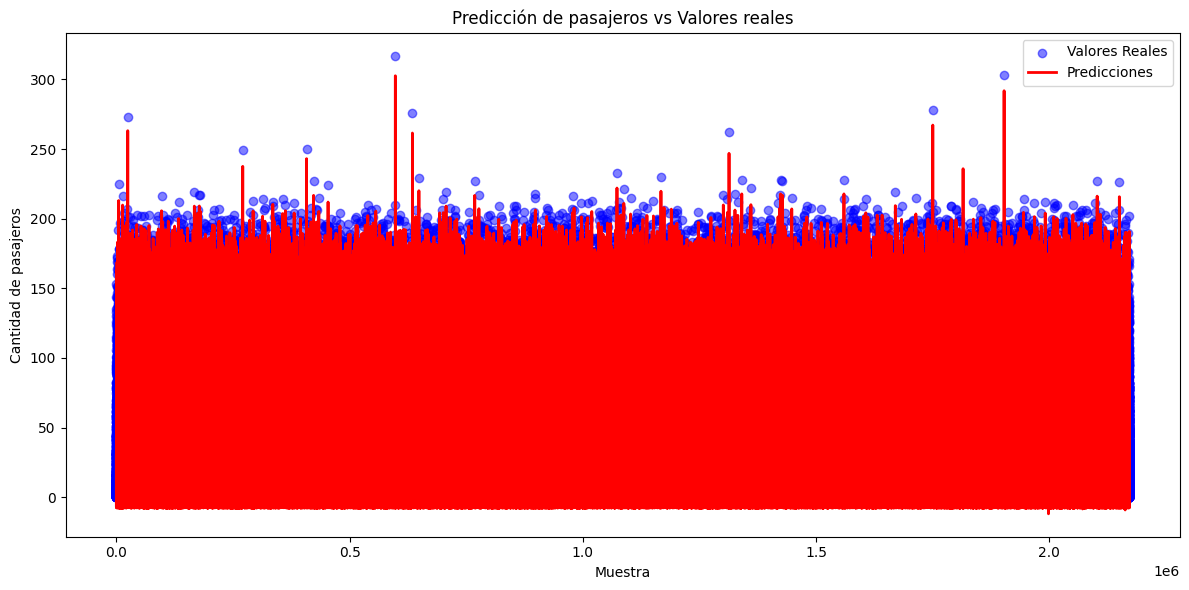

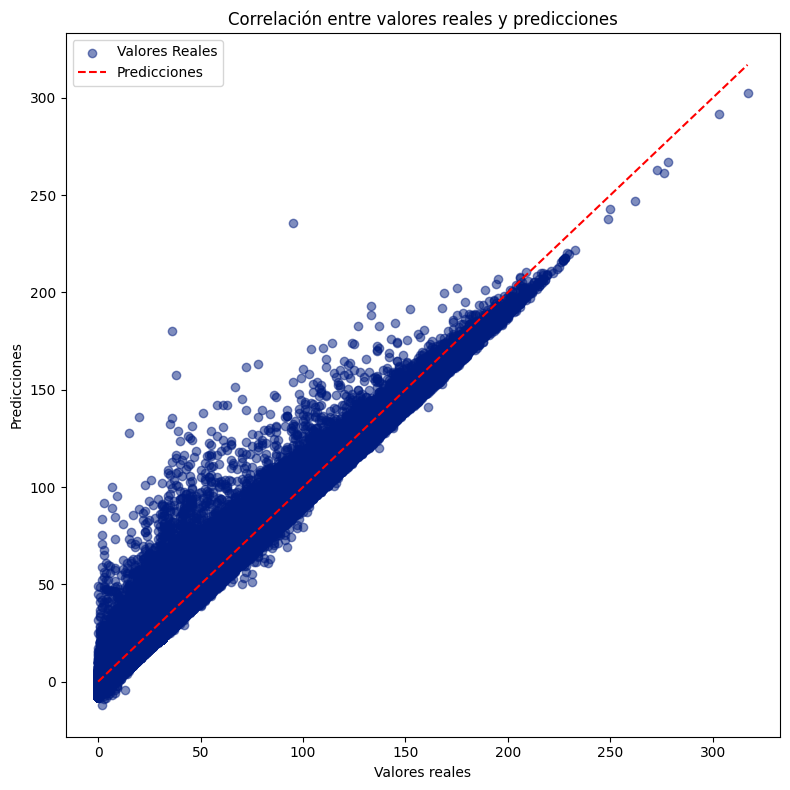

In [45]:
  # Visualizacion grafica de predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.scatter(range(len(predictions)), y_test, color='blue', label='Valores reales', alpha=0.5)
plt.plot(range(len(predictions)), predictions, color='red', label='Predicciones', linewidth=2)
plt.title('Predicción de pasajeros vs Valores reales')
plt.xlabel('Muestra')
plt.ylabel('Cantidad de pasajeros')
plt.legend(labels=['Valores Reales','Predicciones'])
plt.tight_layout()
plt.show()
plt.close()
    
    # Grafico de correlación
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Correlación entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.tight_layout()
plt.legend(labels=['Valores Reales','Predicciones'])
plt.show()
plt.close()

**RESUMEN del Código completo**

1.	Carga de datos: Se lee el dataset y se separa en X (variables predictoras) e y (cantidad de VIAJES pagos).

2.	Preprocesamiento:
- División en entrenamiento (80%) y prueba (20%).
- Normalización con StandardScaler() para mejorar estabilidad numérica.
3.	Modelo MLP:
- Entrada: Capa densa con 64 neuronas y "relu".
- Regularización: Dropout(0.2) para evitar sobreajuste.
- Segunda capa oculta: 32 neuronas con "relu".
- Salida: Una neurona sin activación (regresión).
4.	Compilación:
- Optimizador: Adam.
- Función de pérdida: MSE (Error Cuadrático Medio).
- Métrica: MAE (Error Absoluto Medio).
5.	Entrenamiento:
- 10 épocas.
- batch_size=512 para ahorrar memoria.
6.	Evaluación: Se calcula el error absoluto medio (MAE) y el sobre el conjunto de prueba.

7.  Luego se realizan las predicciones.

8.  Se grafican los resultados ( Reales :y_test) Vs. (Predicciones: Predictions)

**CONCLUSIONES DEL MODELO**

- En resumen, el modelo MLP muestra un buen desempeño general para una primera aproximación:

1. •	Tiene un MAE aceptable, lo que indica que las predicciones están razonablemente cerca de los valores reales.
2. •	El MSE también es bajo y no muestra signos de errores extremos.
3. •	No hay señales de sobreajuste, ya que la pérdida de entrenamiento y validación son similares.
4. •	Es un modelo estable y funcional, pero todavía hay margen de mejora afinando hiperparámetros o ajustando la arquitectura.

- En general, el rendimiento del modelo es bastante eficiente, pero podria mejorar. 
- Para esto, habria que seguir modificando y probando distintos hiperparametros.

**------------------------------------------------------------------------------------------------------------------------**

**POR ULTIMO, GENERO UNA MATRIZ DE CORRELACION**

Este código calcula y visualiza la matriz de correlación de un DataFrame utilizando la biblioteca Plotly Express.

### Propósito
El propósito de este código es:

1. Calcular la matriz de correlación entre las columnas de un DataFrame.
2. Visualizar la matriz de correlación en un diagrama de calor utilizando Plotly Express.

### Funcionamiento
El código:

1. Calcula la matriz de correlación utilizando el método `corr()` del DataFrame.
2. Crea un diagrama de calor utilizando la función `px.imshow()` de Plotly Express.
3. Personaliza el diagrama con opciones como:
- `text_auto=True`: muestra los valores en cada celda.
- `aspect="auto"`: ajusta el aspecto para que sea legible.
- `color_continuous_scale="viridis"`: selecciona la escala de colores.
4. Agrega un título al diagrama.
5. Muestra el diagrama utilizando el método `show()`.

### Salida
El código muestra un diagrama de calor que representa la matriz de correlación entre las columnas del DataFrame.

### Interpretación
El diagrama de calor permite visualizar la correlación entre las columnas del DataFrame. Los colores indican el nivel de correlación:

- Colores cálidos (rojo, naranja): correlación positiva.
- Colores fríos (azul, verde): correlación negativa.
- Colores neutros (blanco, gris): correlación cercana a cero.

In [46]:
import plotly.express as px
import pandas as pd


In [47]:
# Calculo matriz de correlación.
correlation_matrix = df.corr()

In [48]:
import plotly.io as pio
pio.renderers.default = "browser"  

# Creo el diagrama de correlación con Plotly Express
fig = px.imshow(
    correlation_matrix,
    text_auto=True,  # Muestra los valores en cada celda
    aspect="auto",   # Ajusta el aspecto para que sea legible
    color_continuous_scale="viridis", 
    title="Matriz de Correlación"
)

# Mostrar la figura
fig.show()

**------------------------------------------------------------------------------------------------------------------------**

**------------------------------------------------------------------------------------------------------------------------**

# Redes Recurrentes (GRU/LSTM)

**OBJETIVO: Predecir la cantidad de pasajeros pagos (PAX_PAGO) en función de resto de las variables**


In [49]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

EL siguiente código prepara los datos para un modelo de series temporales.

### Propósito
El propósito de este código es:

1. Separar las variables independientes (X) y dependiente (y) del conjunto de datos.
2. Normalizar los datos para mejorar el rendimiento del modelo.
3. Convertir los datos en secuencias para modelado temporal.

### Funcionamiento
El código:

1. Separa las variables independientes (X) y dependiente (y) utilizando `iloc`.
2. Normaliza los datos utilizando `StandardScaler`.
3. Define una función `create_sequences` para convertir los datos en secuencias.
4. La función `create_sequences` itera sobre los datos y crea secuencias de longitud `seq_length`.
5. Cada secuencia consiste en `seq_length` pasos de tiempo y la predicción en el siguiente paso.
6. El código llama a la función `create_sequences` con `seq_length=10` y almacena las secuencias en `X_seq` y `y_seq`.

### Salida
El código produce dos arreglos:

- `X_seq`: un arreglo de secuencias de longitud `seq_length`.
- `y_seq`: un arreglo de predicciones correspondientes a cada secuencia.

### Uso posterior
Los arreglos `X_seq` y `y_seq` pueden ser utilizados para entrenar un modelo de series temporales, como un modelo de redes neuronales recurrentes (RNN) o un modelo de transformador.

In [50]:
# Separo variables independientes (X) y dependiente (y)
X = df.iloc[:, 1:].values  # Todas las columnas excepto PAX_PAGO
y = df.iloc[:, 0].values   # PAX_PAGO

# Normalizo los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convierto datos en secuencias para modelado temporal
def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])  # Secuencia de 10 pasos
        y_seq.append(y[i + seq_length])  # Predicción en el siguiente paso
    return np.array(X_seq), np.array(y_seq)

seq_length = 10  # Número de pasos de tiempo en cada entrada
X_seq, y_seq = create_sequences(X, y, seq_length)

El siguiente código divide los datos preparados para el modelado temporal en conjuntos de entrenamiento y prueba.

### Propósito
El propósito de este código es:

1. Dividir los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.
2. Utilizar el conjunto de entrenamiento para entrenar el modelo.
3. Utilizar el conjunto de prueba para evaluar el rendimiento del modelo.

### Funcionamiento
El código:

1. Utiliza la función `train_test_split` para dividir los datos en conjuntos de entrenamiento y prueba.
2. Especifica la proporción de datos para el conjunto de prueba (`test_size=0.2`).
3. Especifica la semilla para la generación de números aleatorios (`random_state=42`).
4. Divide los datos en cuatro conjuntos:
- `X_train`: datos de entrenamiento para las secuencias.
- `X_test`: datos de prueba para las secuencias.
- `y_train`: datos de entrenamiento para las predicciones.
- `y_test`: datos de prueba para las predicciones.

### Salida
El código produce cuatro conjuntos de datos:

- `X_train`
- `X_test`
- `y_train`
- `y_test`

In [51]:
# Divido en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)


El siguiente código define un modelo de red neuronal recurrente (RNN) utilizando la arquitectura Gated Recurrent Unit (GRU) para series temporales.

### Propósito
El propósito de este código es:

1. Definir un modelo de RNN para predecir valores en una serie temporal.
2. Utilizar la arquitectura GRU para capturar dependencias a largo plazo en los datos.

### Funcionamiento
El código:

1. Crea un modelo secuencial utilizando `Sequential`.
2. Agrega una capa GRU con:
- 64 unidades (neuronas) en la capa.
- `return_sequences=True` para devolver la secuencia completa.
- `input_shape=(seq_length, X_train.shape[2])` para especificar la forma de entrada.
3. Agrega una capa de abandono (Dropout) con una tasa de abandono de 0.2.
4. Agrega otra capa GRU con:
- 32 unidades (neuronas) en la capa.
- `return_sequences=False` para devolver solo el último estado.
5. Agrega una capa densa (Dense) con:
- 16 unidades (neuronas) en la capa.
- Activación ReLU.
6. Agrega una capa de salida densa (Dense) con una sola unidad (neurona) para regresión.

### Salida
El código define un modelo de RNN GRU para series temporales.

In [52]:
# Defino el modelo GRU
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(seq_length, X_train.shape[2])),  # Capa recurrente
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dense(16, activation="relu"),
    Dense(1)  # Capa de salida para regresión
])

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



El siguiente código compila el modelo de red neuronal recurrente (RNN) GRU definido anteriormente.

### Propósito
El propósito de este código es:

1. Especificar el optimizador para ajustar los parámetros del modelo.
2. Especificar la función de pérdida para evaluar el rendimiento del modelo.
3. Especificar las métricas adicionales para evaluar el rendimiento del modelo.

### Funcionamiento
El código:

1. Utiliza el método `compile` del modelo para especificar los detalles de compilación.
2. Especifica el optimizador como "adam", que es un algoritmo de optimización estocástico.
3. Especifica la función de pérdida como "mse" (error cuadrático medio), que es comúnmente utilizada para problemas de regresión.
4. Especifica la métrica adicional como "mae" (error absoluto medio), que proporciona una medida adicional del rendimiento del modelo.

### Salida
El código compila el modelo con los detalles especificados.

In [53]:
# Compilo el modelo
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


El siguiente código entrena el modelo de red neuronal recurrente (RNN) GRU compilado anteriormente.

### Propósito
El propósito de este código es:

1. Ajustar los parámetros del modelo para minimizar la pérdida en los datos de entrenamiento.
2. Evaluar el rendimiento del modelo en los datos de validación durante el entrenamiento.

### Funcionamiento
El código:

1. Utiliza el método `fit` del modelo para iniciar el entrenamiento.
2. Proporciona los datos de entrenamiento (`X_train` y `y_train`) y validación (`X_test` y `y_test`).
3. Especifica el número de épocas (`epochs=10`) para entrenar el modelo.
4. Especifica el tamaño del lote (`batch_size=512`) para entrenar el modelo.
5. Establece el nivel de verbosidad (`verbose=1`) para mostrar información durante el entrenamiento.

### Salida
El código devuelve un objeto `History` que contiene información sobre el entrenamiento, incluyendo:

- La pérdida y las métricas en los datos de entrenamiento y validación en cada época.

In [54]:
# Entreno el modelo
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=10, batch_size=512, verbose=1)



Epoch 1/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 243s 14ms/step - loss: 77.4571 - mae: 1.9052 - val_loss: 0.1301 - val_mae: 0.3007
Epoch 2/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 319s 19ms/step - loss: 0.1244 - mae: 0.2466 - val_loss: 0.3673 - val_mae: 0.5401
Epoch 3/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 1828s 108ms/step - loss: 0.0933 - mae: 0.2138 - val_loss: 1.9251 - val_mae: 1.2268
Epoch 4/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 274s 16ms/step - loss: 0.0737 - mae: 0.1882 - val_loss: 2.2900 - val_mae: 1.3432
Epoch 5/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 273s 16ms/step - loss: 0.0877 - mae: 0.2017 - val_loss: 1.7810 - val_mae: 1.0322
Epoch 6/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 275s 16ms/step - loss: 0.4829 - mae: 0.4625 - val_loss: 0.0872 - val_mae: 0.1936
Epoch 7/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 273s 16ms/step - loss: 1.2519 - mae: 0.6920 - val_loss: 0.7909 - val_mae: 0.4880
Epoch 8/10
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 248s 15ms/step - loss: 22.0660 - mae: 1.7720 - val_loss: 3.8268 - val_mae: 1.2

El siguiente código evalúa el rendimiento del modelo de red neuronal recurrente (RNN) GRU entrenado anteriormente en los datos de prueba.

### Propósito
El propósito de este código es:

1. Evaluar la precisión del modelo en los datos de prueba.
2. Obtener medidas de rendimiento, como el error absoluto medio (MAE).

### Funcionamiento
El código:

1. Utiliza el método `evaluate` del modelo para evaluar su rendimiento en los datos de prueba (`X_test` y `y_test`).
2. Obtiene la pérdida (error cuadrático medio, MSE) y el error absoluto medio (MAE) como medidas de rendimiento.
3. Imprime el valor del MAE con dos decimales.

### Salida
El código muestra el valor del error absoluto medio (MAE) del modelo en los datos de prueba.

### Interpretación
El MAE es una medida de la precisión del modelo. Un valor bajo de MAE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [55]:
#Evaluo el modelo
loss, mae = model.evaluate(X_test, y_test)
print(f'Error absoluto medio (MAE): {mae:.2f}')

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 256s 4ms/step - loss: 558.3344 - mae: 17.9222
Error absoluto medio (MAE): 17.92


El siguiente código utiliza el modelo de red neuronal recurrente (RNN) GRU entrenado para realizar predicciones en los datos de prueba.

### Propósito
El propósito de este código es:

1. Utilizar el modelo entrenado para hacer predicciones en los datos de prueba.
2. Obtener las predicciones en forma de arreglo unidimensional.

### Funcionamiento
El código:

1. Utiliza el método `predict` del modelo para realizar predicciones en los datos de prueba (`X_test`).
2. La función `predict` devuelve un arreglo multidimensional con las predicciones.
3. La función `flatten()` se utiliza para convertir el arreglo multidimensional en un arreglo unidimensional.
4. Las predicciones se almacenan en la variable `predictions2`.

### Salida
El código produce un arreglo unidimensional con las predicciones del modelo en los datos de prueba.

In [56]:
#Realizo las predicciones
predictions2 = model.predict(X_test).flatten()

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 158s 2ms/step


El siguiente código evalúa los resultados de las predicciones realizadas por el modelo de red neuronal recurrente (RNN) GRU.

### Propósito
El propósito de este código es:

1. Calcular el error cuadrático medio (MSE) entre las predicciones y los valores reales.
2. Mostrar el error absoluto medio (MAE) que se calculó anteriormente.

### Funcionamiento
El código:

1. Calcula el error cuadrático medio (MSE) utilizando la fórmula: `MSE = (1/n) * sum((y_true - y_pred) ** 2)`.
2. Utiliza la función `np.mean` para calcular la media de los errores cuadrados.
3. Almacena el resultado en la variable `mse`.
4. Muestra el valor de `mse` en la consola.
5. Muestra el valor del error absoluto medio (MAE) que se calculó anteriormente.

### Salida
El código muestra dos valores:

- El error cuadrático medio (MSE) entre las predicciones y los valores reales.
- El error absoluto medio (MAE) que se calculó anteriormente.

### Interpretación
Los valores de MSE y MAE indican la precisión del modelo. Un valor bajo de MSE y MAE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [57]:
#Evaluo los resultados.
mse = np.mean((y_test - predictions2) ** 2)
print("MSE:" , mse)
print(f'Error absoluto medio (MAE): {mae:.2f}')

MSE: 558.2364017284787
Error absoluto medio (MAE): 17.92


**Visualizacion de una MUESTRA de los Resultados obtenidos**

El siguiente código compara las predicciones realizadas por el modelo con los valores reales y muestra un resumen de las diferencias.

### Propósito
El propósito de este código es:

1. Comparar las predicciones del modelo con los valores reales.
2. Mostrar un resumen de las diferencias entre las predicciones y los valores reales.

### Funcionamiento
El código:

1. Crea un DataFrame llamado `predicciones` que contiene tres columnas: `Datos Reales`, `Predicciones` y `Dif`.
2. La columna `Datos Reales` contiene los valores reales de `y_test`.
3. La columna `Predicciones` contiene las predicciones realizadas por el modelo.
4. La columna `Dif` contiene la diferencia entre los valores reales y las predicciones.
5. Redondea las predicciones y las diferencias a un decimal utilizando la función `round`.
6. Muestra las primeras 20 filas del DataFrame `predicciones` utilizando la función `head`.

### Salida
El código muestra un resumen de las diferencias entre las predicciones y los valores reales para las primeras 20 muestras.

### Interpretación
El resumen muestra la precisión del modelo en las primeras 20 muestras. Las diferencias entre las predicciones y los valores reales indican el error cometido por el modelo.

In [58]:
#predicciones = df
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predictions2, 'Dif': y_test-predictions2})
print('Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales
    Datos Reales  Predicciones   Dif
0              2     21.600000 -19.6
1              6     21.500000 -15.5
2              0     21.500000 -21.5
3             12     -7.900000  19.9
4             82     37.400002  44.6
5              7     21.500000 -14.5
6             20     29.299999  -9.3
7              3     21.600000 -18.6
8             66     24.000000  42.0
9             50     24.000000  26.0
10            32     23.299999   8.7
11            11     -4.100000  15.1
12            23     24.700001  -1.7
13            12      3.000000   9.0
14            58     24.000000  34.0
15            10     -2.300000  12.3
16            36     24.000000  12.0
17            10     -8.300000  18.3
18             6    -14.000000  20.0
19             5     21.500000 -16.5


- El siguiente código tiene como objetivo evaluar y visualizar la precisión de un modelo de predicción aplicado a los datos de pasajeros pagos (PAX_PAGO).
- •	Muestra 50 casos comparando visualmente las predicciones con los datos reales.

¿Para qué sirve?
- •	Evaluar el desempeño del modelo.
- •	Detectar si el modelo está subestimando o sobreestimando los valores reales.
- •	Identificar posibles errores sistemáticos o outliers.
- •	Comunicar resultados de manera clara y visual.


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



MAE (Error absoluto medio): 17.92
RMSE (Raíz del error cuadrático medio): 23.63


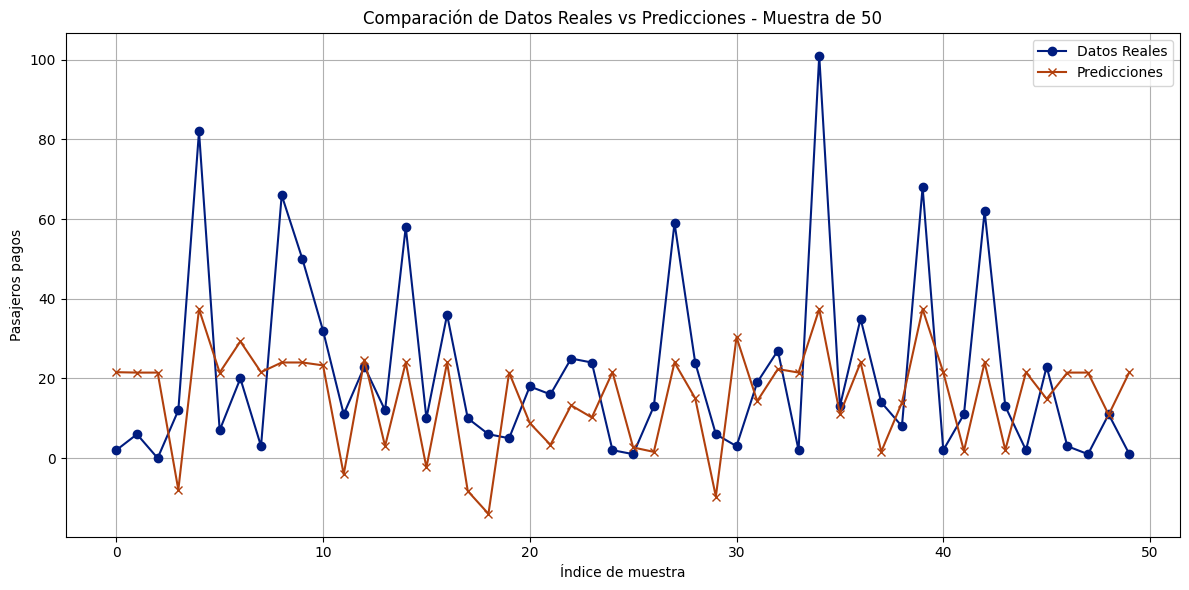

In [60]:
# Creo un DataFrame con los resultados
predicciones = pd.DataFrame({
    'Datos Reales': y_test,
    'Predicciones': predictions2,
    'Dif': y_test - predictions2
})

# Redondeo para mejor presentación
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)

# --- MÉTRICAS DE EVALUACIÓN ---
mae = mean_absolute_error(y_test, predictions2)
rmse = np.sqrt(mean_squared_error(y_test, predictions2))

print(f'\nMAE (Error absoluto medio): {mae:.2f}')
print(f'RMSE (Raíz del error cuadrático medio): {rmse:.2f}')

# --- GRÁFICO DE PREDICCIONES VS REALES ---
plt.figure(figsize=(12, 6))
plt.plot(y_test[:50], label='Datos Reales', marker='o')
plt.plot(predictions2[:50], label='Predicciones', marker='x')
plt.title('Comparación de Datos Reales vs Predicciones - Muestra de 50')
plt.xlabel('Índice de muestra')
plt.ylabel('Pasajeros pagos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Representacion Grafica de los Reusultados**

El siguiente código genera dos gráficos:

1. Un gráfico de dispersión que compara las predicciones del modelo con los valores reales.
2. Un gráfico de dispersión que muestra la correlación entre los valores reales y las predicciones.

### Propósito
El propósito de este código es:

1. Visualizar la precisión del modelo en la predicción de los valores reales.
2. Analizar la correlación entre los valores reales y las predicciones.

### Funcionamiento
El código:

*Gráfico 1: Predicciones vs Valores Reales*

1. Crea un gráfico de dispersión utilizando `plt.scatter` para mostrar los valores reales.
2. Agrega una línea que representa las predicciones del modelo utilizando `plt.plot`.
3. Personaliza el gráfico con título, etiquetas de ejes y leyenda.

*Gráfico 2: Correlación entre Valores Reales y Predicciones*

1. Crea un gráfico de dispersión utilizando `plt.scatter` para mostrar la relación entre los valores reales y las predicciones.
2. Agrega una línea de referencia que indica la relación perfecta entre los valores reales y las predicciones.
3. Personaliza el gráfico con título, etiquetas de ejes y leyenda.

### Salida
El código genera dos gráficos que permiten visualizar la precisión del modelo y la correlación entre los valores reales y las predicciones.

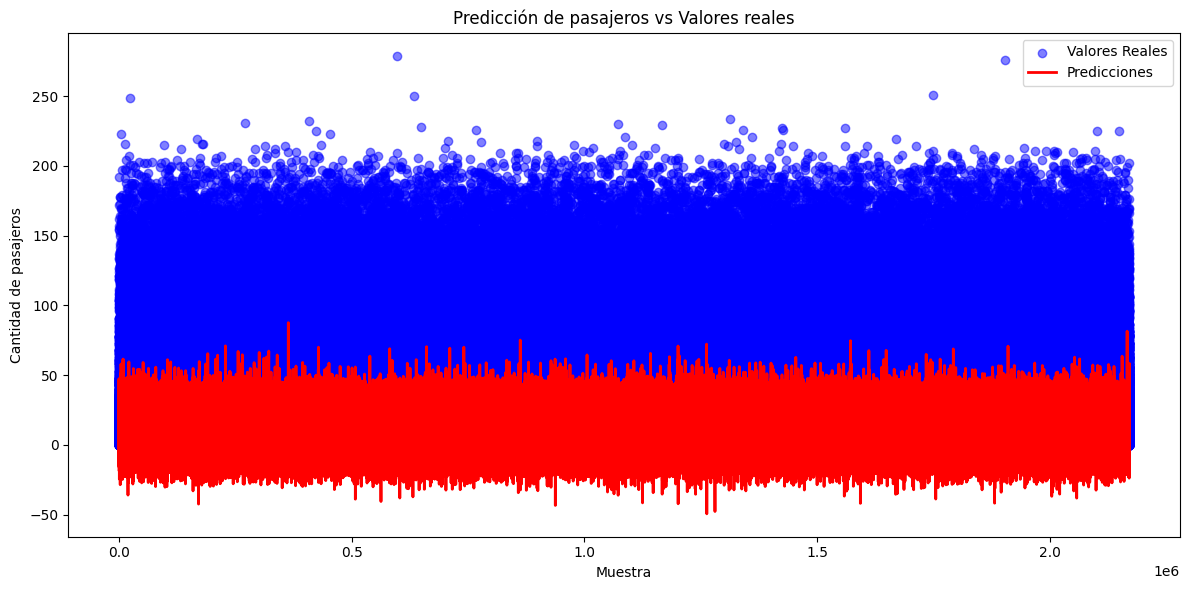

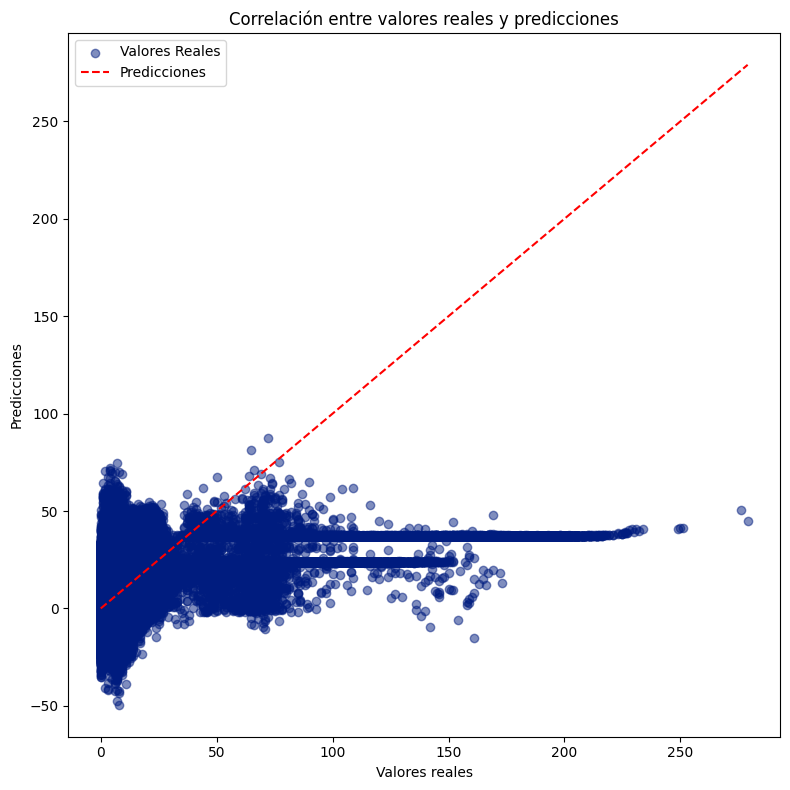

In [61]:
# Visualizo el grafico de predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.scatter(range(len(predictions2)), y_test, color='blue', label='Valores reales', alpha=0.5)
plt.plot(range(len(predictions2)), predictions2, color='red', label='Predicciones', linewidth=2)
plt.title('Predicción de pasajeros vs Valores reales')
plt.xlabel('Muestra')
plt.ylabel('Cantidad de pasajeros')
plt.legend(labels=['Valores Reales','Predicciones'])
plt.tight_layout()
plt.show()
plt.close()
    
    # Grafico correlación
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions2, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Correlación entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.tight_layout()
plt.legend(labels=['Valores Reales','Predicciones'])
plt.show()
plt.close()

**RESUMEN del Código completo**

** 1.Carga y preprocesamiento de datos.
- Se cargan los datos y se separa X (variables predictoras) e y (PAX_PAGO).
- Se normaliza con StandardScaler() para mejorar estabilidad.

** 2.Transformación en secuencias temporales
- Create_sequences(X, y, seq_length=10):
- Toma 10 registros anteriores como entrada para predecir el siguiente.
- Esto permite que la red aprenda patrones temporales.

** 3.Modelo GRU
- Capa GRU de 64 unidades con return_sequences=True para aprender patrones largos.
- Capa Dropout para evitar sobreajuste.
- Segunda capa GRU de 32 unidades sin return_sequences, para reducir la dimensión.
- Capas densas finales para predecir el número de pasajeros.

** 4.Entrenamiento y evaluación
- Se entrena por 10 épocas con batch_size=512 (ajustable según recursos).
- Se evalúa el MAE (Error Absoluto Medio) para medir precisión.

** 5.Se grafican los resultados ( Reales :y_test) Vs. (Predicciones: Predictions)

** Posibles Mejoras
- Probar LSTM en lugar de GRU, aunque consume más memoria.
- Ajustar seq_length (más pasos pueden mejorar precisión, pero aumentan costo computacional).
- Reducir batch size si hay problemas de memoria.

**CONCLUSIONES DEL MODELO** 

El modelo GRU rindió peor que el MLP, tanto en términos de precisión como de generalización. En este caso, parece que:
1. •	Un enfoque MLP (tabular clásico) es más adecuado.
2. •	El uso de secuencias no agrega valor, o requiere otro enfoque para generar las secuencias (por estación, por línea, por hora, etc.).

## CNN 1D (dimension) para Series Temporales.

**Permite capturar patrones temporales sin recurrir a redes recurrentes (GRU/LSTM), lo que lo hace más eficiente en memoria y velocidad**

**OBJETIVO: Predecir la cantidad de pasajeros pagos (PAX_PAGO) en función de resto de las variables**

In [62]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


El siguiente código es similar al anterior, con algunas diferencias:


### Propósito
El propósito de este código es:

1. Preparar los datos para el modelado.
2. Separar las variables independientes (X) de la variable dependiente (y).
3. Normalizar los datos de X para mejorar el rendimiento del modelo.

### Funcionamiento
El código:

1. Selecciona las variables independientes (X) y la variable dependiente (y) del DataFrame `df`.
2. Normaliza los datos de X utilizando `StandardScaler`.
3. Almacena los datos normalizados en la variable `X`.

### Salida
El código produce:

- Una variable `X` que contiene los datos normalizados de las variables independientes.
- Una variable `y` que contiene los datos de la variable dependiente.

In [63]:
# Separo variables independientes (X) y dependiente (y)
X = df.iloc[:, 1:].values  # Todas las columnas excepto PAX_PAGO
y = df.iloc[:, 0].values   # PAX_PAGO

# Normalizo los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

El siguiente código define una función `create_sequences` que convierte los datos en secuencias para modelado temporal.

### Propósito
El propósito de esta función es:

1. Preparar los datos para el modelado temporal.
2. Crear secuencias de datos que puedan ser utilizadas para entrenar un modelo de series temporales.

### Funcionamiento
La función:

1. Toma como entrada los datos `X` y `y`, y la longitud de la secuencia `seq_length`.
2. Inicializa dos listas vacías `X_seq` y `y_seq` para almacenar las secuencias de datos.
3. Recorre los datos `X` y `y` con un bucle `for` que se detiene `seq_length` pasos antes del final de los datos.
4. En cada iteración, agrega una secuencia de `seq_length` pasos de los datos `X` a la lista `X_seq`.
5. En cada iteración, agrega el valor de `y` que corresponde al siguiente paso después de la secuencia de `X` a la lista `y_seq`.
6. Retorna las listas `X_seq` y `y_seq` convertidas en arreglos de NumPy.

### Salida
La función retorna:

- Un arreglo `X_seq` que contiene las secuencias de datos de entrada.
- Un arreglo `y_seq` que contiene los valores de salida correspondientes a cada secuencia.

In [64]:
# Convierto los datos en secuencias para modelado temporal
def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])  # Secuencia de 10 pasos
        y_seq.append(y[i + seq_length])  # Predicción en el siguiente paso
    return np.array(X_seq), np.array(y_seq)

El siguiente código establece la longitud de la secuencia (`seq_length`) en 10 pasos de tiempo y utiliza la función `create_sequences` para convertir los datos en secuencias temporales.

### Propósito
El propósito de este código es:

1. Establecer la longitud de la secuencia para el modelado temporal.
2. Convertir los datos en secuencias temporales utilizando la función `create_sequences`.

### Funcionamiento
El código:

1. Establece la variable `seq_length` en 10, lo que significa que cada secuencia tendrá 10 pasos de tiempo.
2. Llama a la función `create_sequences` con los datos `X` y `y`, y la longitud de la secuencia `seq_length`.
3. La función `create_sequences` convierte los datos en secuencias temporales y retorna los arreglos `X_seq` y `y_seq`.
4. Los arreglos `X_seq` y `y_seq` se almacenan en las variables `X_seq` y `y_seq`.

### Salida
El código produce:

- Un arreglo `X_seq` que contiene las secuencias temporales de los datos de entrada.
- Un arreglo `y_seq` que contiene los valores de salida correspondientes a cada secuencia.

In [65]:
seq_length = 10  # Número de pasos de tiempo en cada entrada
X_seq, y_seq = create_sequences(X, y, seq_length)


El siguiente código agrega una dimensión extra a los datos `X_seq` para que sean compatibles con una red neuronal convolucional (CNN).

### Propósito
El propósito de este código es:

1. Agregar una dimensión extra a los datos `X_seq` para representar el canal (en este caso, 1 canal).
2. Hacer que los datos sean compatibles con una arquitectura de red neuronal convolucional (CNN).

### Funcionamiento
El código:

1. Utiliza la función `np.expand_dims` para agregar una dimensión extra a los datos `X_seq`.
2. Especifica el eje `-1` como el lugar donde se agregará la nueva dimensión. Esto significa que la nueva dimensión se agregará al final de la forma de los datos.

### Salida
El código produce:

- Un arreglo `X_seq` con una dimensión extra agregada, que ahora tiene una forma compatible con una CNN.

In [66]:
# Agrego una dimensión extra para CNN (canal = 1)
X_seq = np.expand_dims(X_seq, axis=-1)

El siguiente código divide los datos preparados en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.

### Propósito
El propósito de este código es:

1. Dividir los datos en conjuntos de entrenamiento y prueba.
2. Utilizar el conjunto de entrenamiento para entrenar el modelo.
3. Utilizar el conjunto de prueba para evaluar el rendimiento del modelo.

### Funcionamiento
El código:

1. Utiliza la función `train_test_split` para dividir los datos en conjuntos de entrenamiento y prueba.
2. Especifica los datos de entrada `X_seq` y `y_seq`.
3. Establece el tamaño del conjunto de prueba en 20% (`test_size=0.2`).
4. Establece la semilla para la generación de números aleatorios (`random_state=42`).
5. Divide los datos en cuatro conjuntos: `X_train`, `X_test`, `y_train` y `y_test`.

### Salida
El código produce:

- Cuatro conjuntos de datos: `X_train`, `X_test`, `y_train` y `y_test`.

In [67]:
# Divido en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

El siguiente código define un modelo de red neuronal convolucional unidimensional (CNN 1D) para series temporales.

### Propósito
El propósito de este código es:

1. Definir una arquitectura de red neuronal convolucional unidimensional (CNN 1D) para series temporales.
2. Utilizar el modelo para realizar predicciones en series temporales.

### Funcionamiento
El código:

1. Utiliza la clase `Sequential` para definir el modelo.
2. Agrega una capa convolucional unidimensional (`Conv1D`) con:
- 64 filtros (`filters=64`).
- Tamaño del kernel de 3 (`kernel_size=3`).
- Activación ReLU (`activation="relu"`).
- Forma de entrada `(seq_length, X_train.shape[2])`.
3. Agrega una capa de max pooling unidimensional (`MaxPooling1D`) con tamaño de pooling de 2 (`pool_size=2`).
4. Agrega una capa de abandono (`Dropout`) con una tasa de abandono de 0.2 (`rate=0.2`).
5. Repite las capas convolucional y de max pooling.
6. Agrega una capa de aplanamiento (`Flatten`) para transformar la salida de la capa convolucional en una forma unidimensional.
7. Agrega una capa densa (`Dense`) con 32 neuronas (`units=32`) y activación ReLU (`activation="relu"`).
8. Agrega una capa de salida densa (`Dense`) con una sola neurona (`units=1`) para regresión.

### Salida
El código define un modelo de red neuronal convolucional unidimensional (CNN 1D) para series temporales.

In [68]:
# Defino el modelo CNN 1D
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(seq_length, X_train.shape[2])),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=32, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation="relu"),
    Dense(1)  # Capa de salida para regresión
])

/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



El siguiente código compila el modelo de red neuronal convolucional unidimensional (CNN 1D) definido anteriormente.

### Propósito
El propósito de este código es:

1. Compilar el modelo de red neuronal convolucional unidimensional (CNN 1D).
2. Especificar el optimizador, la función de pérdida y las métricas de evaluación.

### Funcionamiento
El código:

1. Utiliza el método `compile` del modelo para compilarlo.
2. Especifica el optimizador como "adam" (`optimizer="adam"`), que es un algoritmo de optimización estocástico.
3. Especifica la función de pérdida como "mse" (`loss="mse"`), que es el error cuadrático medio.
4. Especifica la métrica de evaluación como "mae" (`metrics=["mae"]`), que es el error absoluto medio.

### Salida
El código compila el modelo de red neuronal convolucional unidimensional (CNN 1D) con el optimizador, la función de pérdida y las métricas de evaluación especificadas.

In [69]:
# Compilo el modelo
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


El siguiente código entrena el modelo de red neuronal convolucional unidimensional (CNN 1D) compilado anteriormente.

### Propósito
El propósito de este código es:

1. Entrenar el modelo de red neuronal convolucional unidimensional (CNN 1D) con los datos de entrenamiento.
2. Evaluar el rendimiento del modelo con los datos de prueba.

### Funcionamiento
El código:

1. Utiliza el método `fit` del modelo para entrenarlo.
2. Especifica los datos de entrenamiento `X_train` y `y_train`.
3. Especifica los datos de prueba `X_test` y `y_test` como `validation_data`.
4. Establece el número de épocas de entrenamiento en 2 (`epochs=2`).
5. Establece el tamaño del lote en 512 (`batch_size=512`).
6. Establece el nivel de verbosidad en 1 (`verbose=1`), lo que muestra información detallada durante el entrenamiento.

### Salida
El código entrena el modelo y devuelve un objeto `History` que contiene información sobre el rendimiento del modelo durante el entrenamiento.

In [70]:
#Entreno el modelo
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                    epochs=2, batch_size=512, verbose=1)


Epoch 1/2
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 167s 10ms/step - loss: 19.4288 - mae: 1.3849 - val_loss: 5.1395 - val_mae: 1.2064
Epoch 2/2
16965/16965 ━━━━━━━━━━━━━━━━━━━━ 161s 9ms/step - loss: 2.5050 - mae: 0.9114 - val_loss: 63.2681 - val_mae: 6.4495


El siguiente código evalúa el rendimiento del modelo de red neuronal convolucional unidimensional (CNN 1D) en los datos de prueba.

### Propósito
El propósito de este código es:

1. Evaluar el rendimiento del modelo en los datos de prueba.
2. Calcular el error absoluto medio (MAE) del modelo.

### Funcionamiento
El código:

1. Utiliza el método `evaluate` del modelo para evaluar su rendimiento en los datos de prueba `X_test` y `y_test`.
2. El método `evaluate` devuelve dos valores: la pérdida (`loss`) y el error absoluto medio (`mae`).
3. El código imprime el error absoluto medio (`mae`) con dos decimales utilizando una f-string.

### Salida
El código imprime el error absoluto medio (MAE) del modelo en los datos de prueba.

### Interpretación
El error absoluto medio (MAE) es una medida de la precisión del modelo. Un valor bajo de MAE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [71]:
# Evaluo el modelo
loss, mae = model.evaluate(X_test, y_test)
print(f'Error absoluto medio (MAE): {mae:.2f}')

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 175s 3ms/step - loss: 63.3190 - mae: 6.4524
Error absoluto medio (MAE): 6.45


El siguiente código utiliza el modelo de red neuronal convolucional unidimensional (CNN 1D) entrenado para realizar predicciones en los datos de prueba.

### Propósito
El propósito de este código es:

1. Utilizar el modelo entrenado para hacer predicciones en los datos de prueba.
2. Obtener las predicciones en forma de arreglo unidimensional.

### Funcionamiento
El código:

1. Utiliza el método `predict` del modelo para realizar predicciones en los datos de prueba `X_test`.
2. El método `predict` devuelve un arreglo multidimensional con las predicciones.
3. La función `flatten()` se utiliza para convertir el arreglo multidimensional en un arreglo unidimensional.
4. Las predicciones se almacenan en la variable `predictions3`.

### Salida
El código produce un arreglo unidimensional con las predicciones del modelo en los datos de prueba.

In [72]:
#Realizo las predicciones
predictions3 = model.predict(X_test).flatten()

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 74s 1ms/step


El siguiente código evalúa los resultados de las predicciones realizadas por el modelo de red neuronal convolucional unidimensional (CNN 1D).

### Propósito
El propósito de este código es:

1. Calcular el error cuadrático medio (MSE) entre las predicciones y los valores reales.
2. Mostrar el error absoluto medio (MAE) que se calculó anteriormente.

### Funcionamiento
El código:

1. Calcula el error cuadrático medio (MSE) utilizando la fórmula: `MSE = (1/n) * sum((y_true - y_pred) ** 2)`.
2. Utiliza la función `np.mean` para calcular la media de los errores cuadrados.
3. Almacena el resultado en la variable `mse`.
4. Muestra el valor de `mse` en la consola.
5. Muestra el valor del error absoluto medio (MAE) que se calculó anteriormente.

### Salida
El código muestra dos valores:

- El error cuadrático medio (MSE) entre las predicciones y los valores reales.
- El error absoluto medio (MAE) que se calculó anteriormente.

### Interpretación
Los valores de MSE y MAE indican la precisión del modelo. Un valor bajo de MSE y MAE indica que el modelo es preciso en sus predicciones, mientras que un valor alto indica que el modelo tiene un error significativo en sus predicciones.

In [73]:
#Evaluo los resultados.
mse = np.mean((y_test - predictions3) ** 2)
print("MSE:" , mse)
print(f'Error absoluto medio (MAE): {mae:.2f}')

MSE: 63.268239313237615
Error absoluto medio (MAE): 6.45


**Visualizacion de una MUESTRA de los Resultados obtenidos**

El siguiente código compara las predicciones realizadas por el modelo con los valores reales y muestra un resumen de las diferencias.

### Propósito
El propósito de este código es:

1. Comparar las predicciones del modelo con los valores reales.
2. Mostrar un resumen de las diferencias entre las predicciones y los valores reales.

### Funcionamiento
El código:

1. Crea un DataFrame llamado `predicciones` que contiene tres columnas: `Datos Reales`, `Predicciones` y `Dif`.
2. La columna `Datos Reales` contiene los valores reales de `y_test`.
3. La columna `Predicciones` contiene las predicciones realizadas por el modelo.
4. La columna `Dif` contiene la diferencia entre los valores reales y las predicciones.
5. Redondea las predicciones y las diferencias a un decimal utilizando la función `round`.
6. Muestra las primeras 20 filas del DataFrame `predicciones` utilizando la función `head`.

### Salida
El código muestra un resumen de las diferencias entre las predicciones y los valores reales para las primeras 20 muestras.

### Interpretación
El resumen muestra la precisión del modelo en las primeras 20 muestras. Las diferencias entre las predicciones y los valores reales indican el error cometido por el modelo.

In [74]:
predicciones = df
predicciones = pd.DataFrame({'Datos Reales': y_test, 'Predicciones': predictions3, 'Dif': y_test-predictions3})
print('Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales')
predicciones['Predicciones'] = predicciones['Predicciones'].round(1)
predicciones['Dif'] = predicciones['Dif'].round(1)
print(predicciones.head(20))

Comparativo MUESTRA de 20 Predicciones "PAX_PAGO" Vs Datos Reales
    Datos Reales  Predicciones   Dif
0              2    -11.200000  13.2
1              6     -6.600000  12.6
2              0     -6.100000   6.1
3             12      0.500000  11.5
4             82     76.699997   5.3
5              7      3.300000   3.7
6             20     16.200001   3.8
7              3    -14.200000  17.2
8             66     61.799999   4.2
9             50     48.200001   1.8
10            32     33.099998  -1.1
11            11      2.200000   8.8
12            23     21.700001   1.3
13            12     13.400000  -1.4
14            58     51.200001   6.8
15            10      4.700000   5.3
16            36     27.700001   8.3
17            10      6.300000   3.7
18             6      5.000000   1.0
19             5     -8.800000  13.8


**Visualizacion de resultados**

**Representacion Grafica de los Reusultados**

El siguiente código genera dos gráficos:

1. Un gráfico de dispersión que compara las predicciones del modelo con los valores reales.
2. Un gráfico de dispersión que muestra la correlación entre los valores reales y las predicciones.

### Propósito
El propósito de este código es:

1. Visualizar la precisión del modelo en la predicción de los valores reales.
2. Analizar la correlación entre los valores reales y las predicciones.

### Funcionamiento
El código:

*Gráfico 1: Predicciones vs Valores Reales*

1. Crea un gráfico de dispersión utilizando `plt.scatter` para mostrar los valores reales.
2. Agrega una línea que representa las predicciones del modelo utilizando `plt.plot`.
3. Personaliza el gráfico con título, etiquetas de ejes y leyenda.

*Gráfico 2: Correlación entre Valores Reales y Predicciones*

1. Crea un gráfico de dispersión utilizando `plt.scatter` para mostrar la relación entre los valores reales y las predicciones.
2. Agrega una línea de referencia que indica la relación perfecta entre los valores reales y las predicciones.
3. Personaliza el gráfico con título, etiquetas de ejes y leyenda.

### Salida
El código genera dos gráficos que permiten visualizar la precisión del modelo y la correlación entre los valores reales y las predicciones.

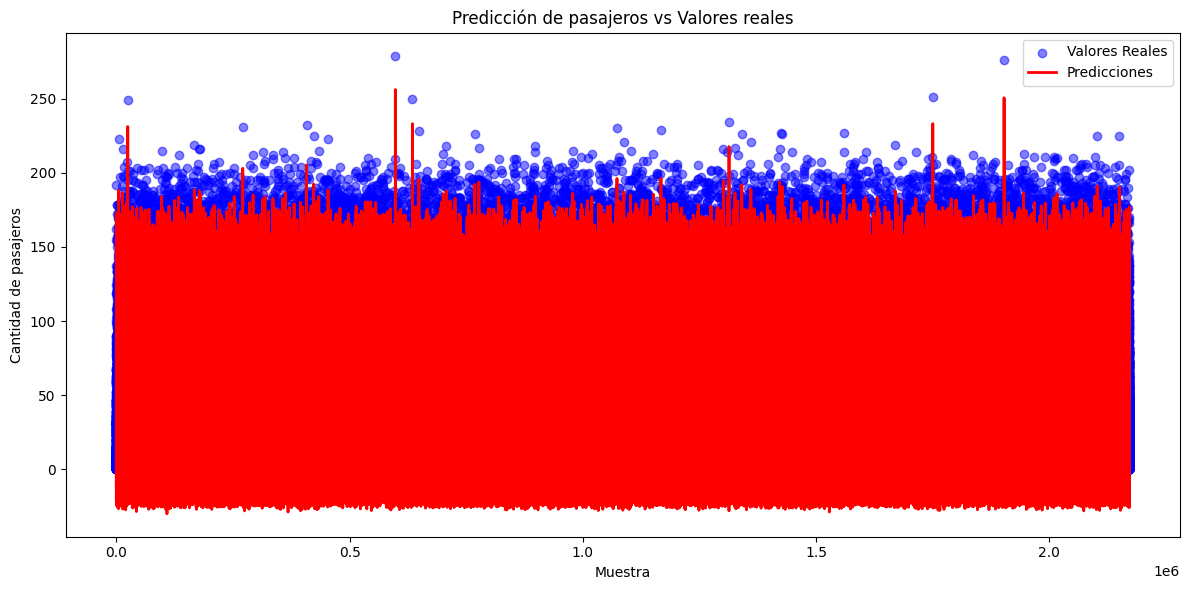

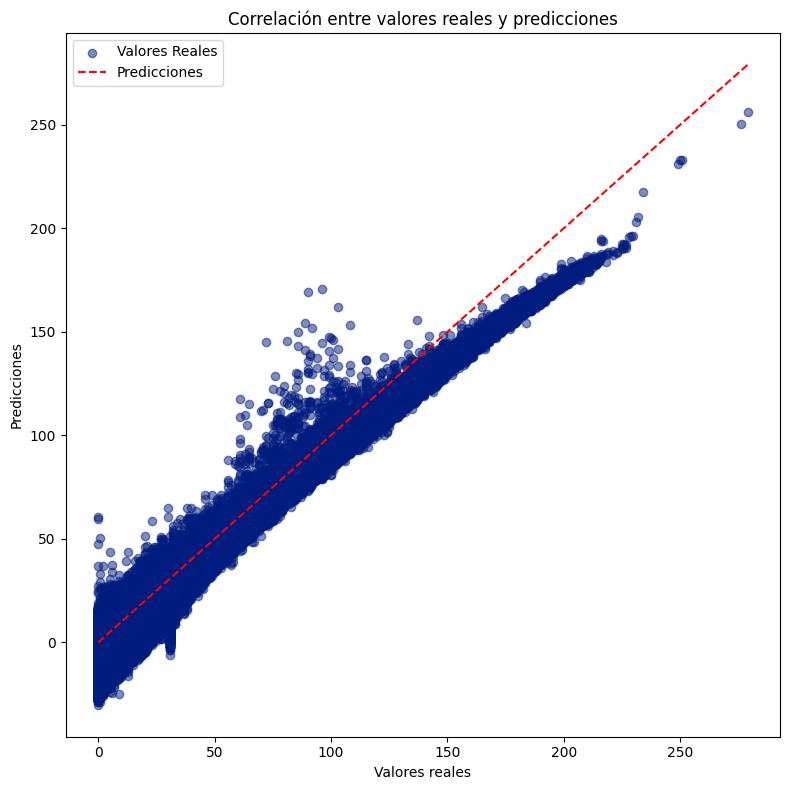

In [75]:
# Realizo el Grafico para visualizar las predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.scatter(range(len(predictions3)), y_test, color='blue', label='Valores reales', alpha=0.5)
plt.plot(range(len(predictions3)), predictions3, color='red', label='Predicciones', linewidth=2)
plt.title('Predicción de pasajeros vs Valores reales')
plt.xlabel('Muestra')
plt.ylabel('Cantidad de pasajeros')
plt.legend(labels=['Valores Reales','Predicciones'])
plt.tight_layout()
plt.show()
plt.close()
    
    # Grafico de correlación
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions3, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Correlación entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.tight_layout()
plt.legend(labels=['Valores Reales','Predicciones'])
plt.show()
plt.close()

**RESUMEN del Código completo**

* 1. Carga y preprocesamiento de datos
- Se cargan los datos y se separa X (variables predictoras) e y (PAX_PAGO).
- Se normaliza con StandardScaler() para mejorar estabilidad.
* 2. Transformación en secuencias temporales
- create_sequences(X, y, seq_length=10):
- Toma 10 registros anteriores como entrada para predecir el siguiente.
- Se añade una dimensión extra (np.expand_dims) para que la CNN lo procese correctamente.
* 3. Modelo CNN 1D
- Capa Conv1D con 64 filtros y kernel de tamaño 3 → detecta patrones temporales.
- MaxPooling1D → reduce dimensionalidad y mejora eficiencia.
- Dropout (0.2) → evita sobreajuste.
- Segunda Conv1D con 32 filtros para refinar la información.
- Capa Flatten para convertir la salida en un vector plano.
- Capa densa de 32 neuronas con "relu".
- Salida con una sola neurona (regresión).
* 4. Entrenamiento y evaluación
- Se entrena por 2 épocas con batch_size=512.
- Se mide el MAE (Error Absoluto Medio) en el test.
* 5. Se grafican los resultados ( Reales :y_test) Vs. (Predicciones: Predictions)


**CONCLUSIONES DEL MODELO**

*Análisis*

La pérdida de prueba (MSE) es relativamente bajo, lo que indica que el modelo está haciendo las predicciones con bastante precision.

Por otro lado, el error absoluto medio (MAE) no es elevado, lo que podría indicar que el modelo está comenzando a realizar predicciones más precisas..

En general, el rendimiento del modelo es bastante eficiente. 

- El modelo CNN 1D aplicado a la predicción de pasajeros pagos muestra un rendimiento inicial aceptable.
- Estos resultados indican un buen ajuste sin errores extremos. 
- El uso de secuencias temporales es apropiado, y la arquitectura CNN ofrece eficiencia computacional, ideal para entornos con recursos limitados. 
- Como mejora, se podria aumentar el número de épocas de entrenamiento y aplicar técnicas de regularización para mejorar la precisión.
- El modelo presenta potencial, pero aún debe optimizarse.  Para esto, habria que seguir modificando y probando distintos hiperparametros.

## Modelo LSTM.

**OBJETIVO: Predecir la cantidad TOTAL de pasajeros pagos (TOTAL) en función de resto de las variables**

In [38]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


El siguiente código selecciona las características relevantes y la variable objetivo para el modelo LSTM.

### Propósito
El propósito de este código es:

1. Seleccionar las características más relevantes que influirán en la predicción de la variable objetivo.
2. Definir la variable objetivo que se desea predecir.

### Funcionamiento
El código:

1. Define una lista `features` que contiene las características seleccionadas.
2. Define la variable `target` como la variable objetivo que se desea predecir.
3. Crea un nuevo DataFrame `data` que contiene solo las características seleccionadas y la variable objetivo.

### Selección de características
Las características seleccionadas son:

- `PAX_PAGO`: número de pasajeros que pagan.
- `LINEA`: línea de transporte.
- `ESTACION`: estación de transporte.
- `MOLINETE`: molinete de transporte.
- `PAX_PASES_PAGOS`: número de pases pagos.
- `PAX_FRANQ`: número de pasajeros franqueados.
- `FECHA`: fecha.
- `HORA`: hora.

### Variable objetivo
La variable objetivo es:

- `TOTAL`: valor total que se desea predecir.

### Salida
El código crea un nuevo DataFrame `data` que contiene las características seleccionadas y la variable objetivo. Este DataFrame se utilizará para entrenar el modelo LSTM.

In [42]:
# Selecciono las características relevantes
features = ['PAX_PAGO', 'LINEA', 'ESTACION', 'MOLINETE', 'PAX_PASES_PAGOS', 'PAX_FRANQ', 'FECHA', 'HORA']
target = 'TOTAL'  # Variable objetivo

data = df[features + [target]]

El siguiente código normaliza los datos utilizando el escalador Min-Max.

### Propósito
El propósito de este código es:

1. Normalizar los datos para que tengan una escala común.
2. Mejorar la estabilidad y la precisión del modelo LSTM.

### Funcionamiento
El código:

1. Importa el escalador Min-Max (`MinMaxScaler`) de la biblioteca Scikit-learn.
2. Crea un objeto `scaler` del escalador Min-Max.
3. Utiliza el método `fit_transform` del escalador para normalizar los datos.

### Normalización
La normalización se realiza de la siguiente manera:

- Los datos se transforman para que tengan un rango entre 0 y 1.
- La media se ajusta a 0 y la varianza se ajusta a 1.

### Salida
El código produce un nuevo conjunto de datos normalizados (`data_scaled`) que se utilizará para entrenar el modelo LSTM.

### Ventajas
La normalización de los datos ofrece varias ventajas:

- Mejora la estabilidad y la precisión del modelo.
- Reduce el impacto de las variables con diferentes escalas.
- Facilita la interpretación de los resultados.

In [43]:
# Normalizo los datos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


El siguientecodigo, crea una función con secuencias de tiempo a partir de los datos normalizados.

### Propósito
El propósito de esta función es:

1. Crear secuencias de tiempo de longitud fija (`seq_length`) a partir de los datos.
2. Preparar los datos para ser utilizados en el modelo LSTM.

### Funcionamiento
La función:

1. Recibe como entrada los datos normalizados (`data`) y la longitud de la secuencia (`seq_length`).
2. Inicializa dos listas vacías (`xs` y `ys`) para almacenar las secuencias de entrada y salida, respectivamente.
3. Recorre los datos utilizando un bucle `for` que itera desde el inicio hasta la longitud de los datos menos la longitud de la secuencia.
4. En cada iteración, extrae una secuencia de longitud `seq_length` de los datos, excluyendo la última columna (el objetivo).
5. La secuencia extraída se almacena en la lista `xs`.
6. El valor del objetivo correspondiente a la secuencia se almacena en la lista `ys`.
7. Después de recorrer todos los datos, la función devuelve las listas `xs` y `ys` convertidas a arrays de NumPy.

### Salida
La función devuelve dos arrays de NumPy:

- `xs`: un array de shape `(n_secuencias, seq_length, n_características)` que contiene las secuencias de entrada.
- `ys`: un array de shape `(n_secuencias,)` que contiene los valores del objetivo correspondientes a cada secuencia.

In [44]:
# Función para crear secuencias de tiempo
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length, :-1]  # Todas las características excepto el objetivo
        y = data[i+seq_length, -1]  # El objetivo
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


El siguiente código define la longitud de la secuencia y crea las secuencias de tiempo utilizando la función `create_sequences`.

### Propósito
El propósito de este código es:

1. Definir la longitud de la secuencia (`seq_length`) que se utilizará para crear las secuencias de tiempo.
2. Crear las secuencias de tiempo utilizando la función `create_sequences`.

### Funcionamiento
El código:

1. Define la longitud de la secuencia (`seq_length`) como 10.
2. Llama a la función `create_sequences` y le pasa como argumentos los datos normalizados (`data_scaled`) y la longitud de la secuencia (`seq_length`).
3. La función `create_sequences` crea las secuencias de tiempo y devuelve dos arrays: `X` y `y`.

### Salida
El código produce dos arrays:

- `X`: un array de shape `(n_secuencias, seq_length, n_características)` que contiene las secuencias de entrada.
- `y`: un array de shape `(n_secuencias,)` que contiene los valores del objetivo correspondientes a cada secuencia.

In [45]:
# Longitud de la secuencia (ajusta según sea necesario)
seq_length = 10

X, y = create_sequences(data_scaled, seq_length)


El siguiente código divide los datos en conjuntos de entrenamiento y prueba utilizando la función `train_test_split`.

### Propósito
El propósito de este código es:

1. Dividir los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.
2. Mantener la secuencia temporal de los datos en el conjunto de entrenamiento y prueba.

### Funcionamiento
El código:

1. Utiliza la función `train_test_split` para dividir los datos en conjuntos de entrenamiento y prueba.
2. Pasa como argumentos los arrays `X` y `y` que contienen las secuencias de entrada y salida, respectivamente.
3. Establece el tamaño del conjunto de prueba en 20% (`test_size=0.2`) del total de los datos.
4. Desactiva el aleatorizado de los datos (`shuffle=False`) para mantener la secuencia temporal de los datos.

### Salida
El código produce cuatro arrays:

- `X_train`: un array que contiene las secuencias de entrada para el conjunto de entrenamiento.
- `X_test`: un array que contiene las secuencias de entrada para el conjunto de prueba.
- `y_train`: un array que contiene los valores del objetivo para el conjunto de entrenamiento.
- `y_test`: un array que contiene los valores del objetivo para el conjunto de prueba.

In [46]:
# Divido en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


El siguiente código construye un modelo de red neuronal recurrente de tipo LSTM (Long Short-Term Memory) utilizando la biblioteca Keras.

### Propósito
El propósito de este código es:

1. Construir un modelo LSTM para predecir valores futuros en una serie temporal.
2. Definir la arquitectura del modelo, incluyendo la cantidad de capas, neuronas y funciones de activación.

### Funcionamiento
El código:

1. Crea un modelo secuencial utilizando la clase `Sequential` de Keras.
2. Agrega una capa LSTM con 50 neuronas, función de activación ReLU y entrada de forma `(X_train.shape[1], X_train.shape[2])`.
3. La capa LSTM devuelve secuencias (`return_sequences=True`) para permitir la conexión con otra capa LSTM.
4. Agrega una capa de abandono (`Dropout`) con una tasa de abandono de 0.2 para regularizar el modelo.
5. Repite los pasos 2-4 para agregar otra capa LSTM y de abandono.
6. Agrega una capa densa (`Dense`) de salida con una sola neurona para predecir el valor futuro.

### Salida
El código produce un modelo LSTM compilado y listo para ser entrenado.

In [47]:
from tensorflow.keras.layers import Input

In [83]:
# Construyo el modelo LSTM
#model = Sequential([
#    Input(shape=(X_train.shape[1], X_train.shape[2])),  # Capa de entrada
#    LSTM(50, activation='relu', return_sequences=True),
#    Dropout(0.2),
#    LSTM(50, activation='relu', return_sequences=False),
#    Dropout(0.2),
#    Dense(1)  # Capa de salida
#])

In [48]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.1),
    Dense(1)
])

2025-04-28 10:42:40.542218: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-04-28 10:42:40.542457: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-28 10:42:40.542603: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-04-28 10:42:40.542635: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-28 10:42:40.542651: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


El siguiente código compila el modelo LSTM definido anteriormente.

### Propósito
El propósito de este código es:

1. Compilar el modelo LSTM con un optimizador, una función de pérdida y métricas de evaluación.
2. Preparar el modelo para ser entrenado.

### Funcionamiento
El código:

1. Utiliza el método `compile` del modelo para compilarlo.
2. Especifica el optimizador como `'adam'`, que es un algoritmo de optimización estocástico.
3. Especifica la función de pérdida como `'mse'` (error cuadrático medio), que es comúnmente utilizada para problemas de regresión.
4. Especifica la métrica de evaluación como `'mae'` (error absoluto medio), que proporciona una medida adicional del rendimiento del modelo.

### Salida
El código compila el modelo LSTM y lo prepara para ser entrenado.

In [49]:
# Compilo el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

El siguiente código entrena el modelo LSTM compilado utilizando los conjuntos de datos de entrenamiento y prueba.

### Propósito
El propósito de este código es:

1. Entrenar el modelo LSTM utilizando los conjuntos de datos de entrenamiento.
2. Evaluar el rendimiento del modelo en el conjunto de prueba durante el entrenamiento.

### Funcionamiento
El código:

1. Utiliza el método `fit` del modelo para entrenarlo.
2. Pasa como argumentos los conjuntos de datos de entrenamiento `X_train` y `y_train`.
3. Especifica la cantidad de épocas de entrenamiento como 2 (`epochs=2`).
4. Especifica el tamaño del lote como 32 (`batch_size=32`).
5. Pasa como argumento el conjunto de prueba (`X_test`, `y_test`) para evaluar el rendimiento del modelo durante el entrenamiento.
6. Establece el nivel de verbosidad en 1 (`verbose=1`) para mostrar información detallada durante el entrenamiento.

### Salida
El código devuelve un objeto `History` que contiene información sobre el rendimiento del modelo durante el entrenamiento.

In [50]:
# Entreno el modelo
history = model.fit(X_train, y_train, epochs=2, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/2


2025-04-28 10:42:54.669514: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


271431/271431 ━━━━━━━━━━━━━━━━━━━━ 2223s 8ms/step - loss: 7.7827e-05 - mae: 0.0054 - val_loss: 1.4819e-05 - val_mae: 0.0025
Epoch 2/2
271431/271431 ━━━━━━━━━━━━━━━━━━━━ 6097s 22ms/step - loss: 5.2914e-05 - mae: 0.0047 - val_loss: 1.7614e-05 - val_mae: 0.0026


**RESULTADO**
- Epoch 1/2
. 271431/271431 ━━━━━━━━━━━━━━━━━━━━ 2256s 8ms/step - loss: 1.3132e-04 - mae: 0.0059 - val_loss: 1.7094e-05 - val_mae: 0.0028
- Epoch 2/2
. 271431/271431 ━━━━━━━━━━━━━━━━━━━━ 2338s 9ms/step - loss: 5.2932e-05 - mae: 0.0047 - val_loss: 1.6975e-05 - val_mae: 0.0027

El siguiente código evalúa el rendimiento del modelo LSTM entrenado utilizando el conjunto de prueba.

### Propósito
El propósito de este código es:

1. Evaluar el rendimiento del modelo LSTM en el conjunto de prueba.
2. Obtener las métricas de evaluación del modelo, como la pérdida y el error absoluto medio.

### Funcionamiento
El código:

1. Utiliza el método `evaluate` del modelo para evaluar su rendimiento en el conjunto de prueba.
2. Pasa como argumentos el conjunto de prueba `X_test` y `y_test`.
3. El método `evaluate` devuelve la pérdida y el error absoluto medio del modelo en el conjunto de prueba.
4. Almacena los resultados en las variables `loss` y `mae`.
5. Imprime los resultados utilizando una f-string.

### Salida
El código imprime la pérdida y el error absoluto medio del modelo en el conjunto de prueba.

### Interpretación
La pérdida y el error absoluto medio son métricas que indican el rendimiento del modelo. Un valor bajo de pérdida y error absoluto medio indica que el modelo es preciso en sus predicciones.

In [51]:
# Evaluo el modelo
loss, mae = model.evaluate(X_test, y_test)
print(f'Loss: {loss}, MAE: {mae}')


67858/67858 ━━━━━━━━━━━━━━━━━━━━ 220s 3ms/step - loss: 1.1739e-05 - mae: 0.0019
Loss: 1.761440398695413e-05, MAE: 0.002617184305563569


El siguiente código utiliza el modelo LSTM entrenado para realizar predicciones en el conjunto de prueba.

### Propósito
El propósito de este código es:

1. Utilizar el modelo LSTM entrenado para realizar predicciones en el conjunto de prueba.
2. Obtener las predicciones del modelo para compararlas con los valores reales.

### Funcionamiento
El código:

1. Utiliza el método `predict` del modelo para realizar predicciones en el conjunto de prueba `X_test`.
2. El método `predict` devuelve las predicciones del modelo para cada muestra en el conjunto de prueba.
3. Almacena las predicciones en la variable `predictions4`.

### Salida
El código produce un array de predicciones del modelo para cada muestra en el conjunto de prueba.

In [52]:
# Realizo predicciones
predictions4 = model.predict(X_test)

67858/67858 ━━━━━━━━━━━━━━━━━━━━ 134s 2ms/step


**Visualizacion de una MUESTRA de los Resultados obtenidos**

El siguiente código compara las predicciones del modelo con los valores reales y muestra los resultados.

### Propósito
El propósito de este código es:

1. Comparar las predicciones del modelo con los valores reales.
2. Mostrar los resultados de la comparación.

### Funcionamiento
El código:

1. Crea un DataFrame `predicciones` que contiene los valores reales (`y_test`), las predicciones del modelo (`predictions4`) y la diferencia entre ellos (`Dif`).
2. Imprime un mensaje que indica que se mostrará un comparativo de 20 predicciones.
3. Redondea las predicciones y la diferencia a un decimal utilizando el método `round`.
4. Muestra las primeras 20 filas del DataFrame `predicciones` utilizando el método `head`.

### Salida
El código muestra un DataFrame que contiene:

- Los valores reales (`Datos Reales`)
- Las predicciones del modelo (`Predicciones`)
- La diferencia entre los valores reales y las predicciones (`Dif`)

### Interpretación
El DataFrame muestra la precisión del modelo en la predicción de los valores de "PAX_PAGO". La columna `Dif` muestra la diferencia entre los valores reales y las predicciones, lo que puede ayudar a identificar patrones o tendencias en los errores del modelo.

El siguiente código imprime los valores reales y las predicciones del modelo para las primeras 10 muestras.

### Propósito
El propósito de este código es:

1. Mostrar los valores reales y las predicciones del modelo para las primeras 10 muestras.
2. Comparar visualmente los valores reales y las predicciones.

### Funcionamiento
El código:

1. Utiliza un bucle `for` para iterar sobre las primeras 10 muestras.
2. En cada iteración, imprime el valor real y la predicción correspondientes utilizando una f-string.
3. Utiliza el método `flatten` para aplanar los arrays de valores reales y predicciones.
4. Utiliza el índice `[0]` para acceder al primer elemento de cada array aplanado.
5. Utiliza `:.5f` para formatear los valores como números flotantes con 5 decimales.

### Salida
El código imprime una lista de pares de valores reales y predicciones, como por ejemplo:

Valor Real: 10.23456, Prediccion: 10.12345
Valor Real: 20.34567, Prediccion: 20.45678
...

### Interpretación
La salida muestra la precisión del modelo en la predicción de los valores de "PAX_PAGO". Los valores reales y las predicciones se pueden comparar visualmente para evaluar la precisión del modelo.

In [53]:
for i in range (10):
    print(f'Valor Real: {y_test[i].flatten()[0]:.5f}, Prediccion: {predictions4[i].flatten()[0]:.5f}')

Valor Real: 0.01534, Prediccion: 0.01766
Valor Real: 0.01840, Prediccion: 0.01810
Valor Real: 0.01534, Prediccion: 0.01839
Valor Real: 0.01840, Prediccion: 0.01875
Valor Real: 0.01840, Prediccion: 0.01801
Valor Real: 0.01534, Prediccion: 0.01805
Valor Real: 0.01840, Prediccion: 0.01784
Valor Real: 0.01534, Prediccion: 0.01825
Valor Real: 0.01840, Prediccion: 0.01848
Valor Real: 0.01840, Prediccion: 0.01850


El siguiente código genera tres gráficos para visualizar y comparar los valores reales y las predicciones del modelo:

### Gráfico 1: Predicciones vs. Valores reales
- Utiliza `plt.scatter` para mostrar los valores reales en azul.
- Utiliza `plt.plot` para mostrar las predicciones en rojo.
- Muestra la cantidad de pasajeros en el eje y y la muestra en el eje x.

### Gráfico 2: Valores reales vs. Predicciones (primeras 10 muestras)
- Utiliza `plt.plot` para mostrar los valores reales y las predicciones para las primeras 10 muestras.
- Muestra el valor real en rojo y la predicción en amarillo.

### Gráfico 3: Correlación entre valores reales y predicciones
- Utiliza `plt.scatter` para mostrar la correlación entre los valores reales y las predicciones.
- Muestra una línea roja para indicar la relación perfecta entre los valores reales y las predicciones.

### Propósito
El propósito de estos gráficos es:

1. Visualizar la precisión del modelo en la predicción de los valores de "PAX_PAGO".
2. Comparar los valores reales y las predicciones del modelo.
3. Evaluar la correlación entre los valores reales y las predicciones.

In [54]:
import matplotlib.pyplot as plt

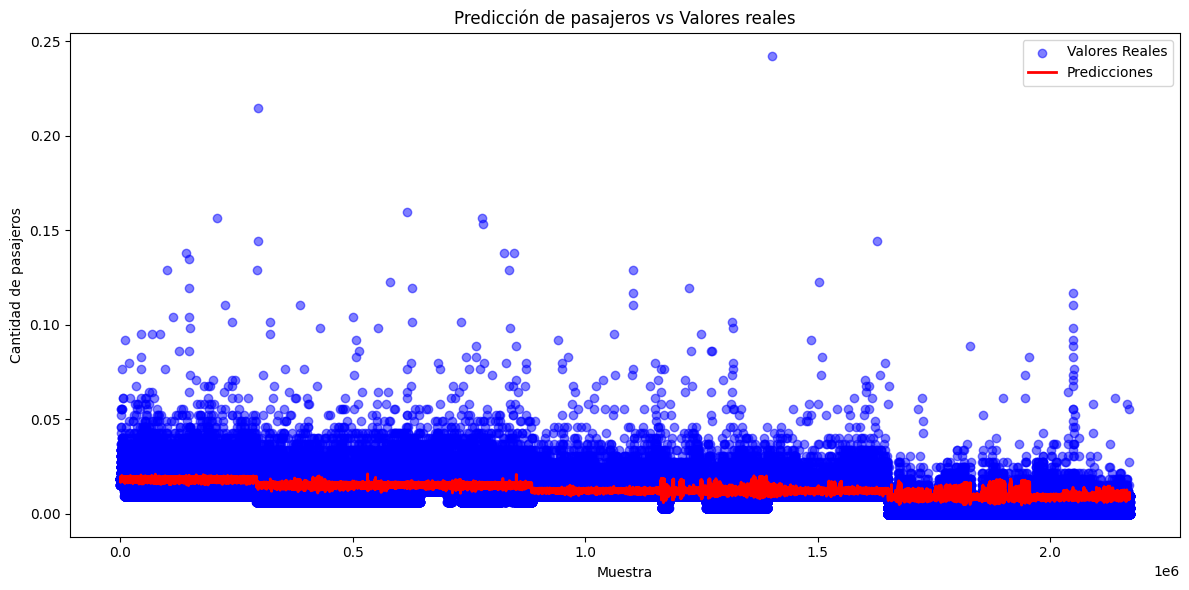

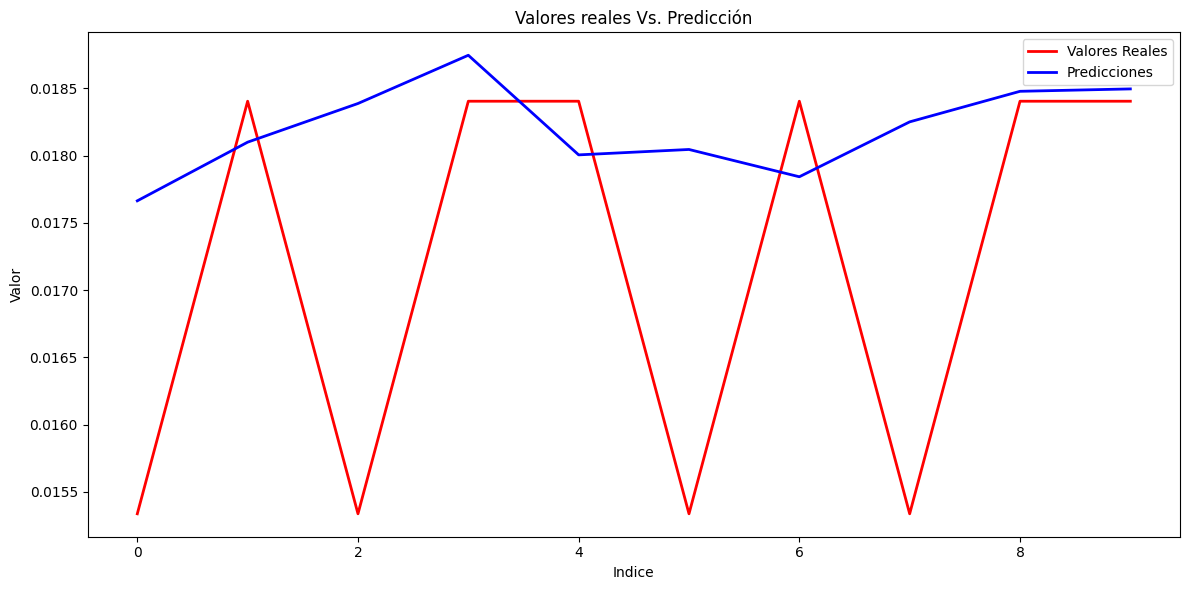

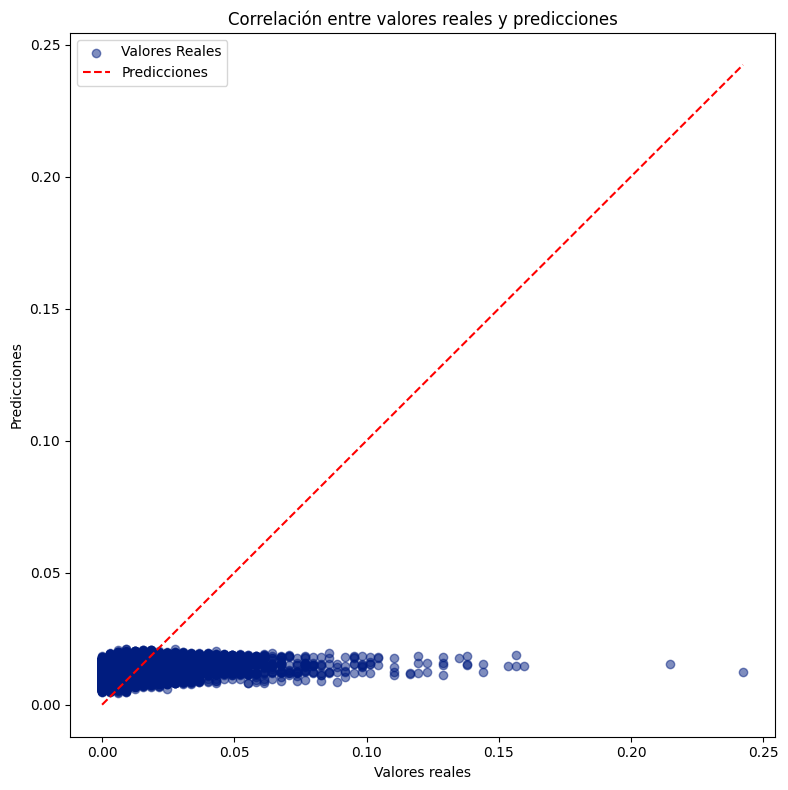

In [55]:

    #Realizo el grafico para visualizar las predicciones vs valores reales
plt.figure(figsize=(12, 6))
plt.scatter(range(len(predictions4)), y_test, color='blue', label='Valores reales', alpha=0.5)
plt.plot(range(len(predictions4)), predictions4, color='red', label='Predicciones', linewidth=2)
plt.title('Predicción de pasajeros vs Valores reales')
plt.xlabel('Muestra')
plt.ylabel('Cantidad de pasajeros')
plt.legend(labels=['Valores Reales','Predicciones'])
plt.tight_layout()
plt.show()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(y_test[:10].flatten(), label='Valor Real', color='red', linewidth=2)
plt.plot(predictions4[:10].flatten(), label='Predicciones', color='blue', linewidth=2)
plt.title('Valores reales Vs. Predicción')
plt.xlabel('Indice')
plt.ylabel('Valor')
plt.legend(labels=['Valores Reales','Predicciones'])
plt.tight_layout()
plt.show()
plt.close()
    
    # Grafico de correlación
plt.figure(figsize=(8, 8))
plt.scatter(y_test, predictions4, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title('Correlación entre valores reales y predicciones')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.tight_layout()
plt.legend(labels=['Valores Reales','Predicciones'])
plt.show()
plt.close()

**CONCLUSIONES DEL MODELO**

Conclusiones del modelo LSTM aplicado al dataset de pasajeros de subterráneos

- Se implementó un modelo de redes neuronales recurrentes (RNN) del tipo LSTM (Long Short-Term Memory) para predecir el volumen total de pasajeros (TOTAL) a partir de diversas características operativas del sistema de subterráneos, incluyendo: la línea, estación, molinete, cantidad de pasajeros pagos, pases pagos, franquicias, fecha y hora.

- Tras la preparación de los datos —incluyendo la normalización mediante MinMaxScaler y la creación de secuencias temporales de longitud 10—, se entrenó el modelo sobre el 80% de los datos, reservando el 20% restante para evaluación.
- El entrenamiento se realizó durante 2 épocas, lo que representa un entrenamiento preliminar de bajo número de iteraciones.

- Los resultados obtenidos: 

1. •	Un error cuadrático medio extremadamente bajo, lo que sugiere que el modelo fue capaz de ajustarse muy bien a las tendencias del conjunto de datos.
2. •	Un MAE muy pequeño, representando un error promedio de predicción del orden de las milésimas respecto a la escala de los datos normalizados, lo que implica alta precisión en la predicción de los valores de pasajeros.

- El modelo LSTM aplicado logro una predicción bastante precisa del volumen de pasajeros, evidenciada por un error cuadrático medio y un MAE extremadamente bajos.
- A pesar del entrenamiento breve (solo 2 épocas), el modelo capturó bien las tendencias del sistema de subterráneos.
- Esto indica que la estructura actual es adecuada para el problema, aunque existe margen de mejora aumentando las épocas y ajustando hiperparámetros.

**En resumen, el modelo es una base sólida para predecir la demanda de pasajeros con alta fiabilidad.**

# MODELO GRU 2.

### Explicacion del codigo realizado paso a paso

- El objetivo principal de este código es limitar el uso de memoria GPU y permitir que TensorFlow utilice la memoria de manera más eficiente.

In [28]:
# Configuración para limitar el uso de memoria
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)


- El siguiente codigo, llama a la función con el valor (Ejemplo:20230220), y la función convertirá ese valor en un objeto 'datetime'  que representa la fecha (Ejemplo: 20 de febrero de 2023).

In [29]:
# Creo la Función para convertir fechas numéricas a datetime
def convert_numeric_date(numeric_date):
    # Asumiendo que numeric_date es un entero en formato YYYYMMDD
    year = numeric_date // 10000
    month = (numeric_date % 10000) // 100
    day = numeric_date % 100
    return datetime.datetime(year, month, day)

- El siguiente codigo, llama a la función con el valor (Ejemplo`930`), y la función convertirá ese valor en una hora decimal (Ejemplo`9.5`), que representa las 9 horas y 30 minutos.

In [30]:
# Creo la Función para convertir horas numéricas a horas
def convert_numeric_time(numeric_time):
    # Asumiendo que numeric_time es un entero en formato HHMM
    hour = numeric_time // 100
    minute = numeric_time % 100
    return hour + minute/60  # Retorna hora como decimal (ej: 9:30 -> 9.5)

In [31]:
# Parámetros de configuración
SEQUENCE_LENGTH = 24  # Secuencia de 24 horas (un día)24
BATCH_SIZE = 64       # Batch pequeño para procesamiento64
EPOCHS = 10           # Número máximo de épocas30
PATIENCE = 5          # Early stopping para evitar sobreajuste5
PCA_COMPONENTS = 10   # Reducir dimensionalidad5

### El propósito de la siguiente función es:

1. Preparar los datos para su uso en modelos de series temporales.
2. Transformar las fechas y horas en formatos numéricos.
3. Ordenar los datos por fecha y hora.
4. Extraer las características (features) y el objetivo (target).
5. Reducir la dimensionalidad de las características utilizando PCA (Análisis de Componentes Principales).
6. Crear secuencias temporales (X) y sus correspondientes objetivos (y).


### La función devuelve dos arrays:

- `X`: Secuencias temporales de características.
- `y`: Objetivos correspondientes a cada secuencia.

In [32]:


# Creo la Función para preparar secuencias temporales
def create_time_sequences(df, seq_length=SEQUENCE_LENGTH):
    print("Preparando secuencias temporales...")
    
    # Ordeno por fecha y hora
    df = df.copy()
    
    # Convertir fechas y horas numéricas
    #df['FECHA'] = df['FECHA_NUMERICA'].apply(convert_numeric_date)
    #df['HORA_DESDE'] = df['DESDE_NUMERICA'].apply(convert_numeric_time)
    
    # Ordeno por fecha y hora
    df = df.sort_values(by=['FECHA', 'HORA'])
    

    # Extraigo características y target
    features = df.iloc[:, 1:].values  # Todas las columnas excepto PAX_PAGO.
    target = df.iloc[: , 0].values       # PAX_PAGO
    
    # Reduzco dimensionalidad usando PCA
    if features.shape[1] > PCA_COMPONENTS:
        print(f"Reduciendo dimensionalidad de {features.shape[1]} a {PCA_COMPONENTS}")
        pca = PCA(n_components=PCA_COMPONENTS)
        features = pca.fit_transform(features)
    
    # Creo secuencias temporales
    X, y = [], []
    for i in range(len(features) - seq_length):
        X.append(features[i:i + seq_length])
        y.append(target[i + seq_length])
    
    return np.array(X), np.array(y)

### El propósito de la siguiente función es:

1. Cargar datos desde un archivo CSV.
2. Preparar los datos para análisis temporal, incluyendo la creación de secuencias temporales.
3. Dividir los datos en conjuntos de entrenamiento y prueba.
4. Normalizar los datos.

### Funcionamiento
La función:

1. Intenta cargar todo el archivo CSV en memoria.
2. Si el archivo es demasiado grande, carga los datos en chunks y muestrea cada chunk.
3. Crea secuencias temporales utilizando la función `create_time_sequences`.
4. Divide los datos en conjuntos de entrenamiento y prueba utilizando la función `train_test_split`.
5. Normaliza los datos utilizando la clase `MinMaxScaler`.

### Salida
La función devuelve los conjuntos de entrenamiento y prueba normalizados:

- `X_train`: Conjunto de entrenamiento de características.
- `X_test`: Conjunto de prueba de características.
- `y_train`: Conjunto de entrenamiento de objetivos.
- `y_test`: Conjunto de prueba de objetivos.

In [33]:
# Función para cargar y preparar los datos
def prepare_temporal_data(file_path, sample_frac=0.1):
    print("Cargando datos para análisis temporal...")
    
    # Por ser un conjunto de datos muy grandes, uso una muestra representativa.
    try:
        # Intento cargar todo primero
        df = pd.read_csv(file_path)
        if len(df) > 1000000:  # Si los datos son demasiado grandes
            df = df.sample(frac=sample_frac, random_state=42)
    except MemoryError:
        # Si hay problemas de memoria, cargar en chunks y muestrear
        chunks = []
        for chunk in pd.read_csv(file_path, chunksize=100000):
            chunks.append(chunk.sample(frac=sample_frac, random_state=42))
        df = pd.concat(chunks)
    
    print(f"Datos cargados. Forma: {df.shape}")
    
    # Creo secuencias temporales
    X, y = create_time_sequences(df)
    print(f"Secuencias creadas. X shape: {X.shape}, y shape: {y.shape}")
    
    # Divido en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Normalizo los datos
    scaler = MinMaxScaler()
    # Reshape para normalizar
    n_samples, n_timesteps, n_features = X_train.shape
    X_train_reshaped = X_train.reshape(n_samples * n_timesteps, n_features)
    X_train_normalized = scaler.fit_transform(X_train_reshaped)
    X_train = X_train_normalized.reshape(n_samples, n_timesteps, n_features)
    
    # Normalizo conjunto de test
    n_samples, n_timesteps, n_features = X_test.shape
    X_test_reshaped = X_test.reshape(n_samples * n_timesteps, n_features)
    X_test_normalized = scaler.transform(X_test_reshaped)
    X_test = X_test_normalized.reshape(n_samples, n_timesteps, n_features)
    
    # Libera memoria
    del df
    gc.collect()
    
    return X_train, X_test, y_train, y_test

### El siguiente código define varias funciones para construir y entrenar un modelo de red neuronal recurrente (RNN) con una arquitectura GRU (Gated Recurrent Unit) para predecir series temporales:

### Funciones
1. *build_gru_model*: Construye un modelo GRU con dos capas de GRU y una capa densa para la salida.
2. *train_rnn_model*: Entrena el modelo GRU con estrategias para ahorrar memoria, incluyendo la preparación de datos temporales, la construcción del modelo, el entrenamiento con callbacks y la evaluación del modelo.
3. *reducir_fecha_numerica*: Reduce una fecha numérica en formato YYYYMMDD a un formato más compacto.

### Propósito
El propósito de este código es:

1. Construir un modelo GRU para predecir series temporales.
2. Entrenar el modelo con estrategias para ahorrar memoria.
3. Evaluar el rendimiento del modelo.

### Funcionamiento
La función *train_rnn_model*:

1. Prepara los datos temporales utilizando la función *prepare_temporal_data*.
2. Construye el modelo GRU utilizando la función *build_gru_model*.
3. Entrena el modelo con callbacks para optimizar el entrenamiento.
4. Evalúa el rendimiento del modelo en el conjunto de prueba.

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

**Creacion del modelo GRU**

In [ ]:
#Al final de todo el ejercicio, se encuentran otros modelos RNN que pueden ser utilizados para comparar el rendimiento.
#Para Reemplazar por otros modelos--------------------------------------
def build_gru_model(input_shape):
    model = Sequential([
        GRU(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model
#Reemplazar hasta aqui---------------------------------------------------


def train_rnn_model(file_path, model_save_path='gru_model.keras'):
    # Preparar datos
    X_train, X_test, y_train, y_test = prepare_temporal_data(file_path)

    # Construyo el modelo
    model = build_gru_model((X_train.shape[1], X_train.shape[2]))
    print(model.summary())

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=model_save_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    # Entreno el modelo
    print("Iniciando entrenamiento del modelo temporal...")
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluación
    print("Evaluando modelo temporal...")
    test_results = model.evaluate(X_test, y_test, verbose=1)
    print(f"Test loss (MSE): {test_results[0]}")
    print(f"Test MAE: {test_results[1]}")

    # Visualización
    visualize_temporal_predictions(model, X_test, y_test)
    plot_training_history(history)

    return model, history

def reducir_fecha_numerica(fecha_numerica):
    year = fecha_numerica // 10000
    month = (fecha_numerica % 10000) // 100
    day = fecha_numerica % 100
    return year % 100 * 10000 + month * 100 + day

### El siguiente código define una función llamada `visualize_temporal_predictions`

### Propósito
El propósito de esta función es:

1. Visualizar las predicciones del modelo en comparación con los valores reales.
2. Mostrar la correlación entre los valores reales y las predicciones.

### Funcionamiento
La función:

1. Selecciona una muestra aleatoria de los datos de prueba (`X_test` y `y_test`).
2. Realiza predicciones sobre la muestra seleccionada utilizando el modelo proporcionado.
3. Grafica las predicciones en comparación con los valores reales utilizando una gráfica de dispersión y una línea para las predicciones.
4. Grafica la correlación entre los valores reales y las predicciones utilizando una gráfica de dispersión y una línea de referencia para la correlación perfecta.

### Parámetros
La función acepta los siguientes parámetros:

- `model`: El modelo de aprendizaje automático que se utiliza para realizar las predicciones.
- `X_test`: Los datos de entrada de prueba.
- `y_test`: Los datos de salida de prueba.
- `samples`: El número de muestras que se seleccionan aleatoriamente para la visualización. El valor predeterminado es 100.

### Salida
La función genera dos gráficos:

1. Compara las predicciones del modelo con los valores reales.
2. Muestra la correlación entre los valores reales y las predicciones.

Ambos se guardan en archivos PNG y se muestran en la pantalla.

In [36]:
# Función para visualizar predicciones temporales
def visualize_temporal_predictions(model, X_test, y_test, samples=100):
    # Selecciono una muestra para visualizar
    indices = np.random.choice(len(X_test), min(samples, len(X_test)), replace=False)
    X_sample = X_test[indices]
    y_sample = y_test[indices]
    
    # Realizo las predicciones
    predictions = model.predict(X_sample).flatten()
    
    # Grafico las predicciones vs valores reales
    plt.figure(figsize=(12, 6))
    plt.scatter(range(len(predictions)), y_sample, color='blue', label='Valores reales', alpha=0.5)
    plt.plot(range(len(predictions)), predictions, color='red', label='Predicciones', linewidth=2)
    plt.title('Predicción de pasajeros vs Valores reales')
    plt.xlabel('Muestra')
    plt.ylabel('Cantidad de pasajeros')
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.savefig('temporal_predictions.png')
    plt.close()
    
    # Grafico de correlación
    plt.figure(figsize=(8, 8))
    plt.scatter(y_sample, predictions, alpha=0.5)
    plt.plot([min(y_sample), max(y_sample)], [min(y_sample), max(y_sample)], 'r--')
    plt.title('Correlación entre valores reales y predicciones')
    plt.xlabel('Valores reales')
    plt.ylabel('Predicciones')
    plt.tight_layout()
    plt.savefig('temporal_correlation.png')
    plt.legend()
    plt.show()
    plt.close()

El siguiente código define una función llamada `plot_training_history` que se utilizara para graficar el historial de entrenamiento de un modelo de red neuronal recurrente (RNN).

### Propósito
El propósito de esta función es:

1. Visualizar la pérdida (MSE) durante el entrenamiento y la validación.
2. Visualizar el error absoluto medio (MAE) durante el entrenamiento y la validación.

### Funcionamiento
La función:

1. Crea una figura con dos subgráficos.
2. En el primer subgráfico, grafica la pérdida (MSE) durante el entrenamiento y la validación.
3. En el segundo subgráfico, grafica el error absoluto medio (MAE) durante el entrenamiento y la validación.
4. Añade títulos, etiquetas y leyendas a los gráficos.
5. Muestra los gráficos y los guarda como un archivo PNG.

### Parámetros
La función acepta un parámetro:

- `history`: El historial de entrenamiento del modelo, que contiene las métricas de pérdida y MAE durante el entrenamiento y la validación.

### Salida
- La función genera una figura con dos subgráficos que muestran la pérdida y el MAE durante el entrenamiento y la validación.
- Por ultimo, se guarda como un archivo PNG llamado `training_history_rnn.png`.

In [37]:
# Función para graficar historial de entrenamiento
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Gráfico de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida durante entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (MSE)')
    plt.show()
    plt.legend()
    
    # Gráfico de MAE
    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Entrenamiento')
    plt.plot(history.history['val_mae'], label='Validación')
    plt.title('Error Absoluto Medio durante entrenamiento')
    plt.xlabel('Época')
    plt.ylabel('MAE')
    plt.legend()
    plt.show()
    plt.tight_layout()
    plt.savefig('training_history_rnn.png')
    plt.close()

### El siguiente código define una función llamada `analyze_temporal_patterns`.

### Propósito
El propósito de esta función es:

1. Analizar los patrones temporales en un conjunto de datos.
2. Identificar los patrones de comportamiento en función del día de la semana y la hora del día.

### Funcionamiento
La función:

1. Carga un conjunto de datos desde un archivo CSV.
2. Prepara los datos convirtiendo las fechas y horas en formatos numéricos.
3. Agrupa los datos por día de la semana y hora del día.
4. Calcula el promedio de pasajeros para cada día de la semana y hora del día.
5. Visualiza los patrones temporales utilizando gráficos de barras.

### Parámetros
La función acepta dos parámetros:

- `model`: Un modelo de aprendizaje automático (no se utiliza en esta función).
- `file_path`: La ruta del archivo CSV que contiene los datos.

### Salida
La función devuelve un diccionario que contiene los patrones temporales detectados:

- `dia_semana`: Un DataFrame que contiene el promedio de pasajeros para cada día de la semana.
- `hora`: Un DataFrame que contiene el promedio de pasajeros para cada hora del día.

Por ultimo, se guarda una imagen PNG llamada `temporal_patterns.png` que muestra los patrones temporales detectados.

In [38]:
# Creo una Función para detectar patrones temporales
def analyze_temporal_patterns(model, file_path):
    # Cargo los datos (muestra pequeña para análisis)
    df = pd.read_csv(file_path, nrows=10000)
    
    # Preparo los datos
    df['FECHA'] = df['FECHA'].apply(convert_numeric_date)
    df['HORA'] = df['HORA'].apply(convert_numeric_time)
    
    # Agrupo por día de la semana y hora
    df['DIA_SEMANA'] = df['FECHA'].dt.dayofweek
    df['HORA'] = df['HORA'].astype(int)
    
    # Análizo por día de la semana
    dia_semana_avg = df.groupby('DIA_SEMANA')['PAX_PAGO'].mean().reset_index()
    
    # Análizo por hora
    hora_avg = df.groupby('HORA')['PAX_PAGO'].mean().reset_index()
    
    # Visualizo los patrones por día de la semana
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.bar(dia_semana_avg['DIA_SEMANA'], dia_semana_avg['PAX_PAGO'])
    plt.title('Promedio de pasajeros por día de la semana')
    plt.xlabel('Día de la semana (0=Lunes, 6=Domingo)')
    plt.ylabel('Promedio de pasajeros')
    plt.legend()
    plt.show()
    
    # Visualizo los patrones por hora
    plt.subplot(1, 2, 2)
    plt.bar(hora_avg['HORA'], hora_avg['PAX_PAGO'])
    plt.title('Promedio de pasajeros por hora del día')
    plt.xlabel('Hora del día')
    plt.ylabel('Promedio de pasajeros')
    plt.tight_layout()
    plt.savefig('temporal_patterns.png')
    plt.legend()
    plt.show()
    plt.close()
    
    return {"dia_semana": dia_semana_avg, "hora": hora_avg}

El siguiente código define la función principal `main` que ejecuta el programa de análisis de series temporales utilizando redes neuronales recurrentes (RNN).

### Propósito
El propósito de esta función es:

1. Entrenar un modelo RNN para predecir series temporales.
2. Analizar los patrones temporales en los datos.
3. Mostrar algunos resultados del análisis.

### Funcionamiento
La función:

1. Llama a la función `train_rnn_model` para entrenar un modelo RNN con los datos del archivo CSV especificado en `file_path`.
2. Llama a la función `analyze_temporal_patterns` para analizar los patrones temporales en los datos.
3. Muestra algunos resultados del análisis, incluyendo los patrones por día de la semana y hora.

### Parámetros
La función acepta un parámetro:

- `file_path`: La ruta del archivo CSV que contiene los datos.
- En nuestro caso, el archivo generado inicialmente "df2014DL.csv".

### Salida
- La función no devuelve ningún valor, pero muestra algunos resultados del análisis en la consola.

### Ejecución
- La función se ejecuta cuando el programa se inicia, gracias a la línea `if __name__ == "__main__": main()`. 
- Esto garantiza que la función `main` se ejecute solo cuando el programa se ejecuta directamente, y no cuando se importa como módulo en otro programa.

Cargando datos para análisis temporal...
Datos cargados. Forma: (1085724, 9)
Preparando secuencias temporales...
Secuencias creadas. X shape: (1085700, 24, 8), y shape: (1085700,)


2025-04-28 15:09:46.606350: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-04-28 15:09:46.606374: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-04-28 15:09:46.606385: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-04-28 15:09:46.606401: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-28 15:09:46.606409: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/venv_subte/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument t

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 128)        │        52,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,305 (352.75 KB)

 Trainable params: 90,305 (352.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Iniciando entrenamiento del modelo temporal...
Epoch 1/10


2025-04-28 15:09:47.134250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


10854/10857 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 645.7216 - mae: 17.5262
Epoch 1: val_loss improved from inf to 538.00482, saving model to gru_model.keras
10857/10857 ━━━━━━━━━━━━━━━━━━━━ 147s 13ms/step - loss: 645.6985 - mae: 17.5258 - val_loss: 538.0048 - val_mae: 16.0406
Epoch 2/10
10853/10857 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 551.2656 - mae: 16.0096
Epoch 2: val_loss did not improve from 538.00482
10857/10857 ━━━━━━━━━━━━━━━━━━━━ 146s 13ms/step - loss: 551.2637 - mae: 16.0095 - val_loss: 538.4766 - val_mae: 16.1589
Epoch 3/10
10856/10857 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 545.6516 - mae: 15.9329
Epoch 3: val_loss improved from 538.00482 to 536.56989, saving model to gru_model.keras
10857/10857 ━━━━━━━━━━━━━━━━━━━━ 149s 14ms/step - loss: 545.6515 - mae: 15.9329 - val_loss: 536.5699 - val_mae: 15.9777
Epoch 4/10
10855/10857 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 541.1926 - mae: 15.8540
Epoch 4: val_loss did not improve from 536.56989
10857/10857 ━━━━━━━━━━━━━━━

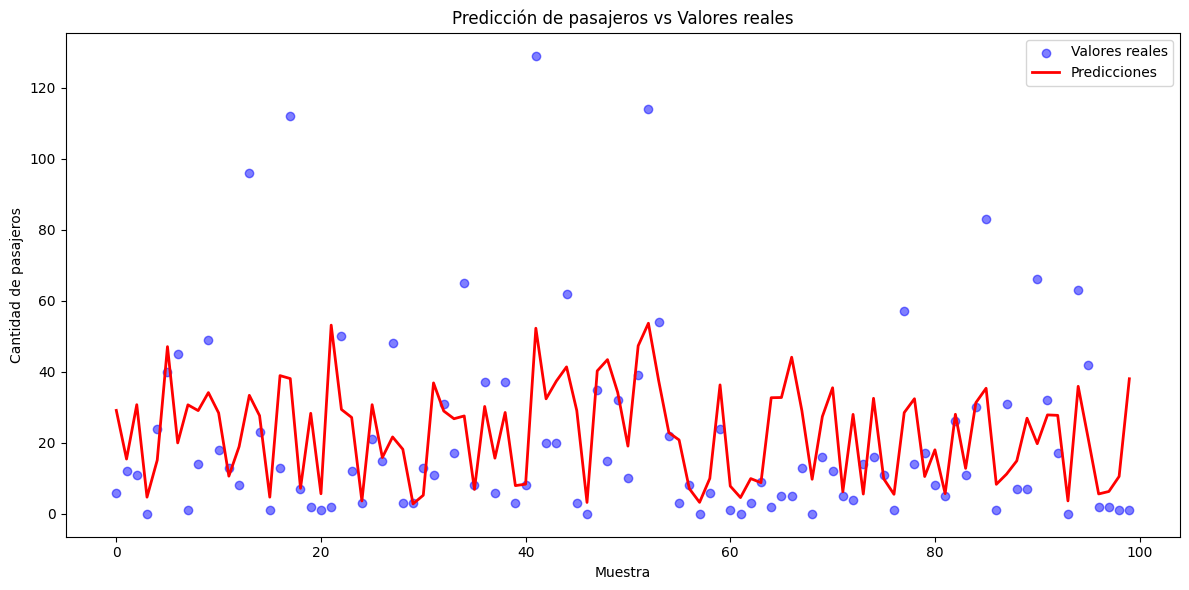

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_71892/2425718852.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


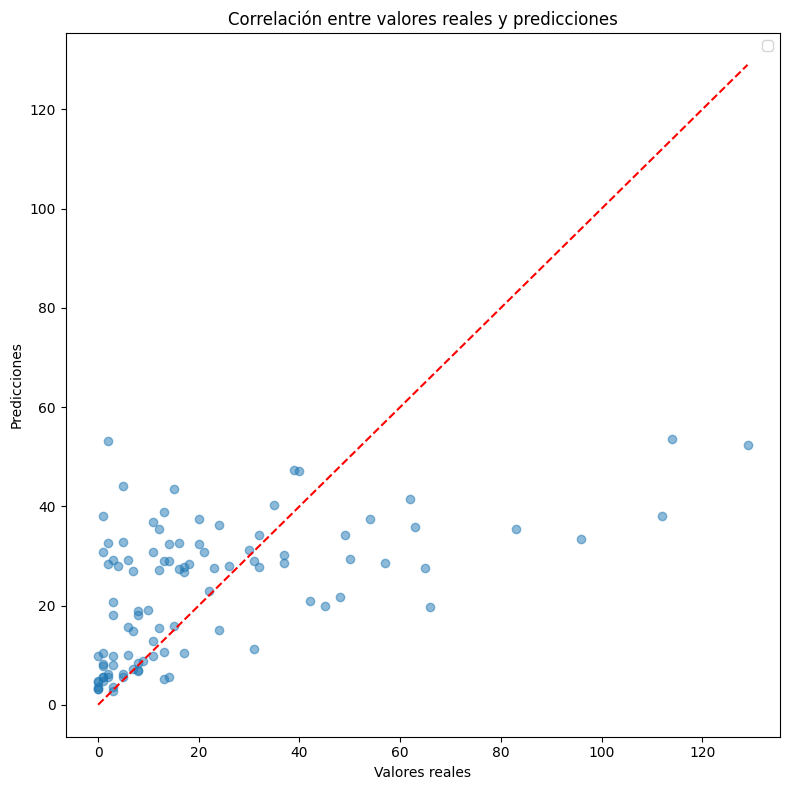

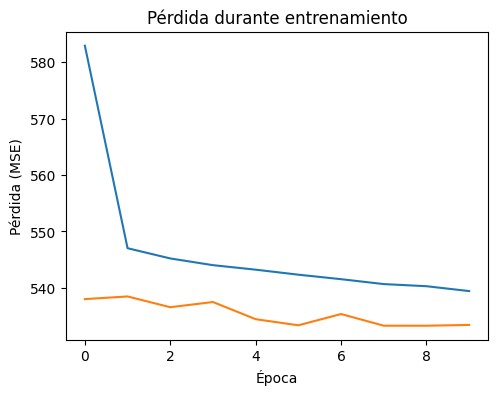

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_71892/2578077243.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


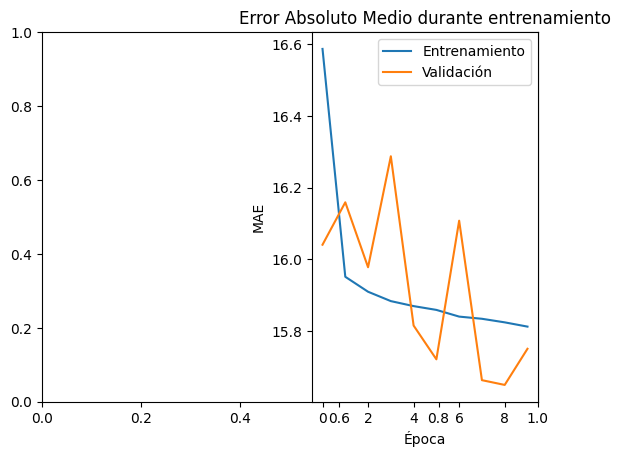

Entrenamiento de modelo temporal completo.


/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_71892/3886147266.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


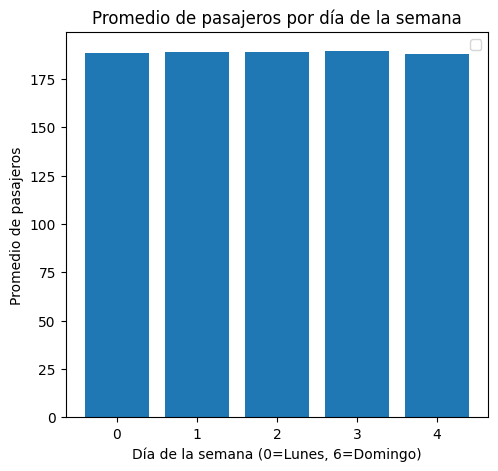

/var/folders/mc/x95ytzzn5z35gdz502qgy2f80000gn/T/ipykernel_71892/3886147266.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


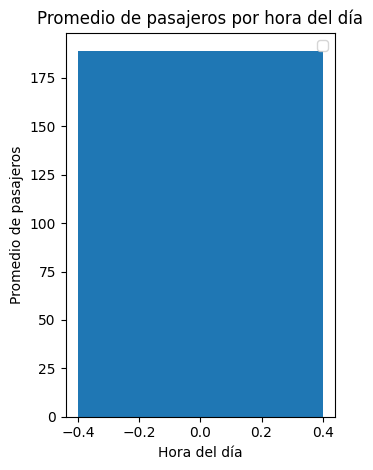

Análisis de patrones temporales completado.

Patrones por día de la semana:
   DIA_SEMANA    PAX_PAGO
0           0  188.338060
1           1  189.117433
2           2  189.110483
3           3  189.619120
4           4  187.599553

Patrones por hora:
   HORA  PAX_PAGO
0     0  188.8411


In [39]:
# Función principal (para esta funcion, se debe utilizar el archivo df2014DL.csv, el cual es generado automaticamente al correr el código)
# Aproximadamente en la linea 38.
def main(file_path='/Users/claudiocastaneda/Downloads/PROYECTO SUBTE/df2014DL.csv'):
    model, history = train_rnn_model(file_path)
    print("Entrenamiento de modelo temporal completo.")
    
    # Analizo los patrones temporales
    patterns = analyze_temporal_patterns(model, file_path)
    print("Análisis de patrones temporales completado.")
    
    # Mustro algunos resultados
    print("\nPatrones por día de la semana:")
    print(patterns["dia_semana"])
    print("\nPatrones por hora:")
    print(patterns["hora"])

# Funcion para ejecutar el programa
if __name__ == "__main__":
    main()

**CONCLUSIONES DEL MODELO**

**1. Evaluación de Resultados:**
	
- •	Un MSE más bajo indica mejor desempeño; sin embargo, su valor absoluto depende de la escala del target (PAX_PAGO).
- •	Esto implica que en promedio, el modelo se equivoca por ±16 pasajeros al hacer una predicción.
- •	Dependiendo del rango típico de PAX_PAGO (por ejemplo, si son cientos o miles de pasajeros por hora), este error puede considerarse pequeño o moderado.



**2. Otros:**

a) Modelo:
- •	La arquitectura GRU utilizada (128 + 64 unidades) es adecuada para capturar dependencias temporales de mediana duración, como las variaciones horarias diarias.
- •	La reducción de dimensionalidad con PCA a 10 componentes ayudó probablemente a estabilizar el entrenamiento, evitando ruido de características menos relevantes.
- •	El uso de EarlyStopping y Dropout permitió controlar el sobreajuste, logrando que la generalización al conjunto de test sea razonablemente buena.

b) Desempeño:
- •	El MAE obtenido sugiere que el modelo capta bastante bien las tendencias del flujo de pasajeros, aunque puede cometer errores importantes en situaciones de alta variabilidad (por ejemplo, eventos especiales o anomalías no representadas en el set de entrenamiento).
- •	El valor de MSE relativamente alto respecto al MAE sugiere que existen outliers (predicciones con errores grandes), que elevan el MSE más que el MAE.

c) Datos:
- •	La muestra utilizada (10%) y el preprocesamiento fueron adecuados para manejar la escala de datos muy grande.
- •	Sin embargo, tomar una muestra puede haber omitido algunos patrones raros o ciclos anuales, dependiendo de cómo se realizó el sampling.



**3. Hiperparametros para seguir optimizando el modelo:**

- •	Incrementar EPOCHS a 30 y PATIENCE a 10: Esto daria entrenamientos más prolongados.
- •	Optimizar el tamaño de secuencia: Probar secuencias de 48 horas o 72 horas para capturar también efectos de ciclo semanal (por ejemplo, diferencias entre días laborales y fines de semana).
- •	Modificar (batch size, learning rate) usando técnicas automáticas (GridSearch, etc.).
- •	Evaluar por segmentos: Analizar el error en distintos horarios (pico vs. valle) para ver si el modelo falla sistemáticamente en ciertas franjas.
- •	Agregar variables externas: Datos como feriados, clima, eventos especiales, podrían explicar parte del error residual.
- •	Reentrenar usando toda la muestra: Si los recursos computacionales lo permiten, se podría usar un 100% del dataset, esto mejoraria aún más la precisión.



**4. Conclusión Final**

- El modelo GRU entrenado demuestra un comportamiento sólido para lacpredicción de pasajeros por hora, con errores medios razonables y capacidad de generalización.
- Aún así, existen oportunidades de mejora mediante la incorporación de más datos, más contexto externo, y un ajuste fino de hiperparámetros.


**OTROS HIPERPARAMETROS TESTEADOS**

Copiar y reemplazar en el codigo mas arriba

Original

In [ ]:
def build_gru_model(input_shape):
    model = Sequential([
        GRU(128, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

**Test N2**

In [ ]:
#Modelo GRU (más ligero que LSTM)
def build_gru_model(input_shape):
    model = Sequential([
        # Capa GRU - más eficiente que LSTM
        GRU(32, input_shape=input_shape, return_sequences=True,
            recurrent_dropout=0.0),  # Sin dropout recurrente para ahorrar memoria
        Dropout(0.2),
        
        # Segunda capa GRU
        GRU(16, recurrent_dropout=0.0),
        Dropout(0.2),
        
        # Capa de salida
        Dense(1)
    ])

**Test N3**

In [ ]:
def build_gru_model(input_shape):
    model = Sequential([
        GRU(64,input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(32, return_sequences=False), 
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam',loss='mse', metrics=['mae'])
    return model

**Test N4**

In [ ]:
def build_gru_model(input_shape):
    model = Sequential([
        GRU(128,input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(64,return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam',loss='mse', metrics=['mae'])
    return model

La pérdida de prueba (MSE) ha disminuido ligeramente, lo que indica que el modelo está haciendo predicciones más precisas.

- Test loss (MSE): 656.7206420898438
- Test MAE: 18.352981567382812